# Vaccine Response Analysis
**Dataset:** BNT162b2 vaccination time course (GEO GSE171964)


## Background
This dataset profiles PBMCs collected at baseline and after BNT162b2 vaccination, capturing short‑term immune dynamics.

**Important Methodological Notes**
**Single‑arm longitudinal study:**
- All participants received vaccine
- Analyses focus on **within‑participant** changes over time
- We do not estimate treatment effects versus an unvaccinated control

**Time axis:**
- We use **Day 0 vs Day 7** as the primary comparison

**Analysis strategy:**
- Participant‑level aggregation avoids treating cells as independent
- Cross‑sectional summaries are descriptive; inference uses paired comparisons
- Multiple testing is controlled using FDR (alpha = 0.25)

**Sampling and scope:**
- We restrict to participants with both Day 0 and Day 7 samples
- For speed, we cap the number of participants and cells per participant/day/cell type


## 1. Setup


In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import sctrial as st
import scipy.sparse as sp
from statsmodels.stats.multitest import multipletests

pd.options.mode.chained_assignment = None

# Configuration
SEED = 42
MIN_PAIRED = 4
MIN_GENES_FOR_SCORE = 5
FDR_ALPHA = 0.25

sc.settings.set_figure_params(dpi=120)


## 2. Data Loading and Processing


In [2]:
# Dataset loader and helpers (from sctrial)
from sctrial.datasets import load_vaccine_gse171964, verify_paired_participants, ensure_fdr


### 2.1 Load processed AnnData


In [3]:
adata = load_vaccine_gse171964(
    max_participants=30,
    max_cells_per_group=200,
    seed=SEED,
)

print(adata)
print("Obs columns:")
print(sorted(adata.obs.columns.tolist()))


Loaded processed vaccine dataset (GSE171964): 21331 cells, 20102 genes
Processed file: /Users/omarm/Documents/Research/projects/sc-trialdiff/data/processed/vaccine_gse171964_day0_day7.h5ad
Days: [0 7]
Participants: 6
Cell types: 18
AnnData object with n_obs × n_vars = 21331 × 20102
    obs: 'pt_id', 'day', 'clustnm', 'sample_id'
    uns: 'processing_params'
    layers: 'counts'
Obs columns:
['clustnm', 'day', 'pt_id', 'sample_id']


### 2.2 Quick exploratory summaries


Days: [0 7]
Participants: 6
Cell types: 18
Participants per day:
day
0    6
7    6
Name: pt_id, dtype: int64


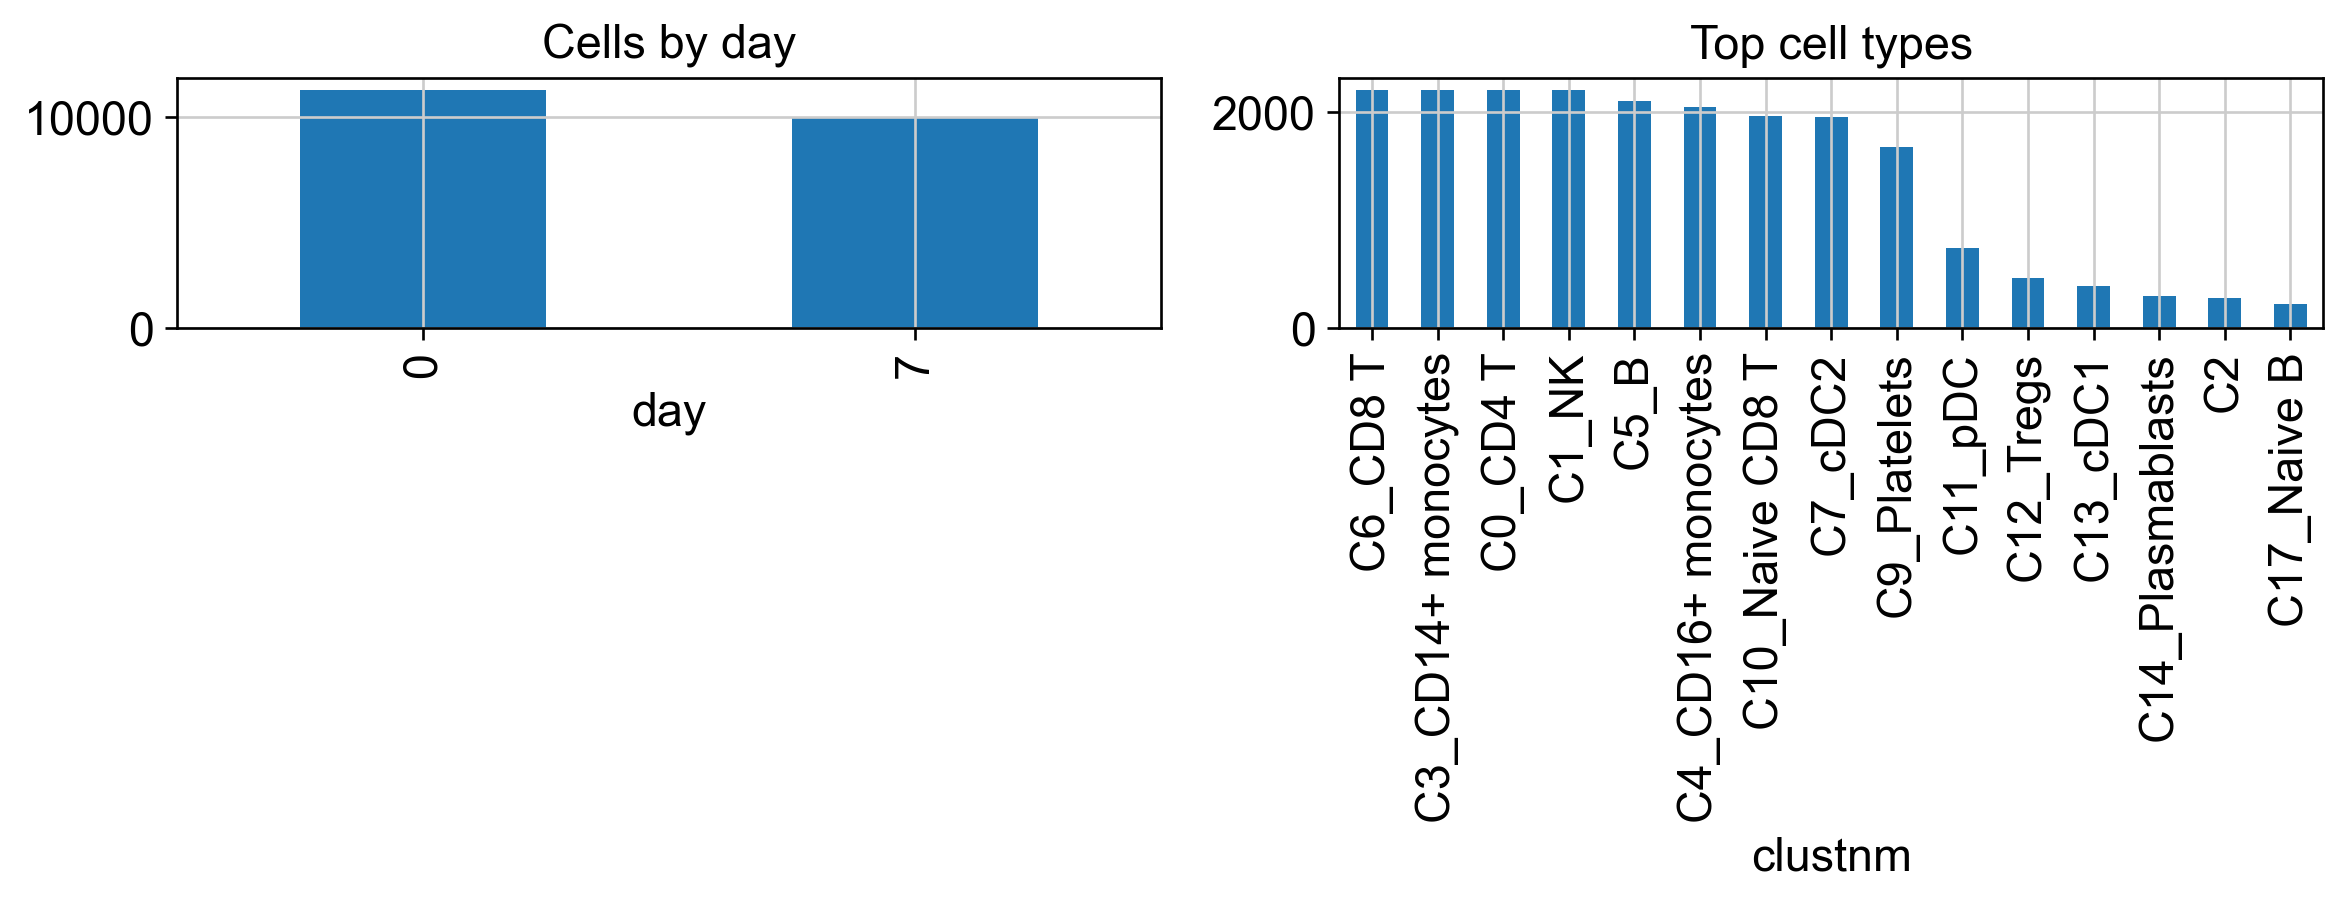

In [4]:
print("Days:", adata.obs["day"].unique())
print("Participants:", adata.obs["pt_id"].nunique())
print("Cell types:", adata.obs["clustnm"].nunique())

# Participants per day (before pairing restriction for analysis)
pt_per_day = adata.obs.groupby("day")["pt_id"].nunique().sort_index()
print("Participants per day:")
print(pt_per_day)

# Cell counts
eday_counts = adata.obs["day"].value_counts().sort_index()
ct_counts = adata.obs["clustnm"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
eday_counts.plot(kind="bar", ax=axes[0], title="Cells by day")
ct_counts.plot(kind="bar", ax=axes[1], title="Top cell types")
plt.tight_layout(); plt.show()


## 3. Trial Design and Timepoint Strategy


In [5]:
# Ensure log1p CPM
if "log1p_cpm" not in adata.layers:
    adata = st.add_log1p_cpm_layer(adata, counts_layer="counts", out_layer="log1p_cpm")

# Standardize metadata
adata.obs["visit"] = adata.obs["day"].astype(str)
adata.obs["participant_id"] = adata.obs["pt_id"].astype(str)
adata.obs["arm"] = "Vaccinated"
adata.obs["cell_type"] = adata.obs["clustnm"].astype(str)

visit_col = "visit"
visits = [v for v in ["0", "7"] if v in adata.obs[visit_col].unique()]

# Participant-level pairing
participant_summary = (
    adata.obs.groupby("participant_id")[visit_col].apply(set).reset_index()
)
participant_summary["has_day0"] = participant_summary[visit_col].apply(lambda x: "0" in x)
participant_summary["has_day7"] = participant_summary[visit_col].apply(lambda x: "7" in x)
participant_summary["is_paired"] = participant_summary["has_day0"] & participant_summary["has_day7"]
paired_ids = set(participant_summary.loc[participant_summary["is_paired"], "participant_id"])

n_paired = len(paired_ids)
print(f"Paired participants (0 vs 7): {n_paired}")

# Analysis subset: paired participants only
adata_analysis = adata[adata.obs["participant_id"].isin(paired_ids)].copy()
print(f"Analysis subset cells: {adata_analysis.n_obs}")

# Covariates (if available)
candidate_covariates = ["age", "sex", "batch", "site"]
covariates = [c for c in candidate_covariates if c in adata.obs.columns]
print("Covariates available (not modeled here):", covariates)

# Design object (single arm); arm labels are placeholders for API consistency
# We rely on paired within-participant tests, not treated vs control inference.
design = st.TrialDesign(
    participant_col="participant_id",
    visit_col=visit_col,
    arm_col="arm",
    arm_treated="Vaccinated",
    arm_control="Vaccinated",
    celltype_col="cell_type",
)


Paired participants (0 vs 7): 6


Analysis subset cells: 21331
Covariates available (not modeled here): []


### 3.1 Exploratory plots of cell types per visit


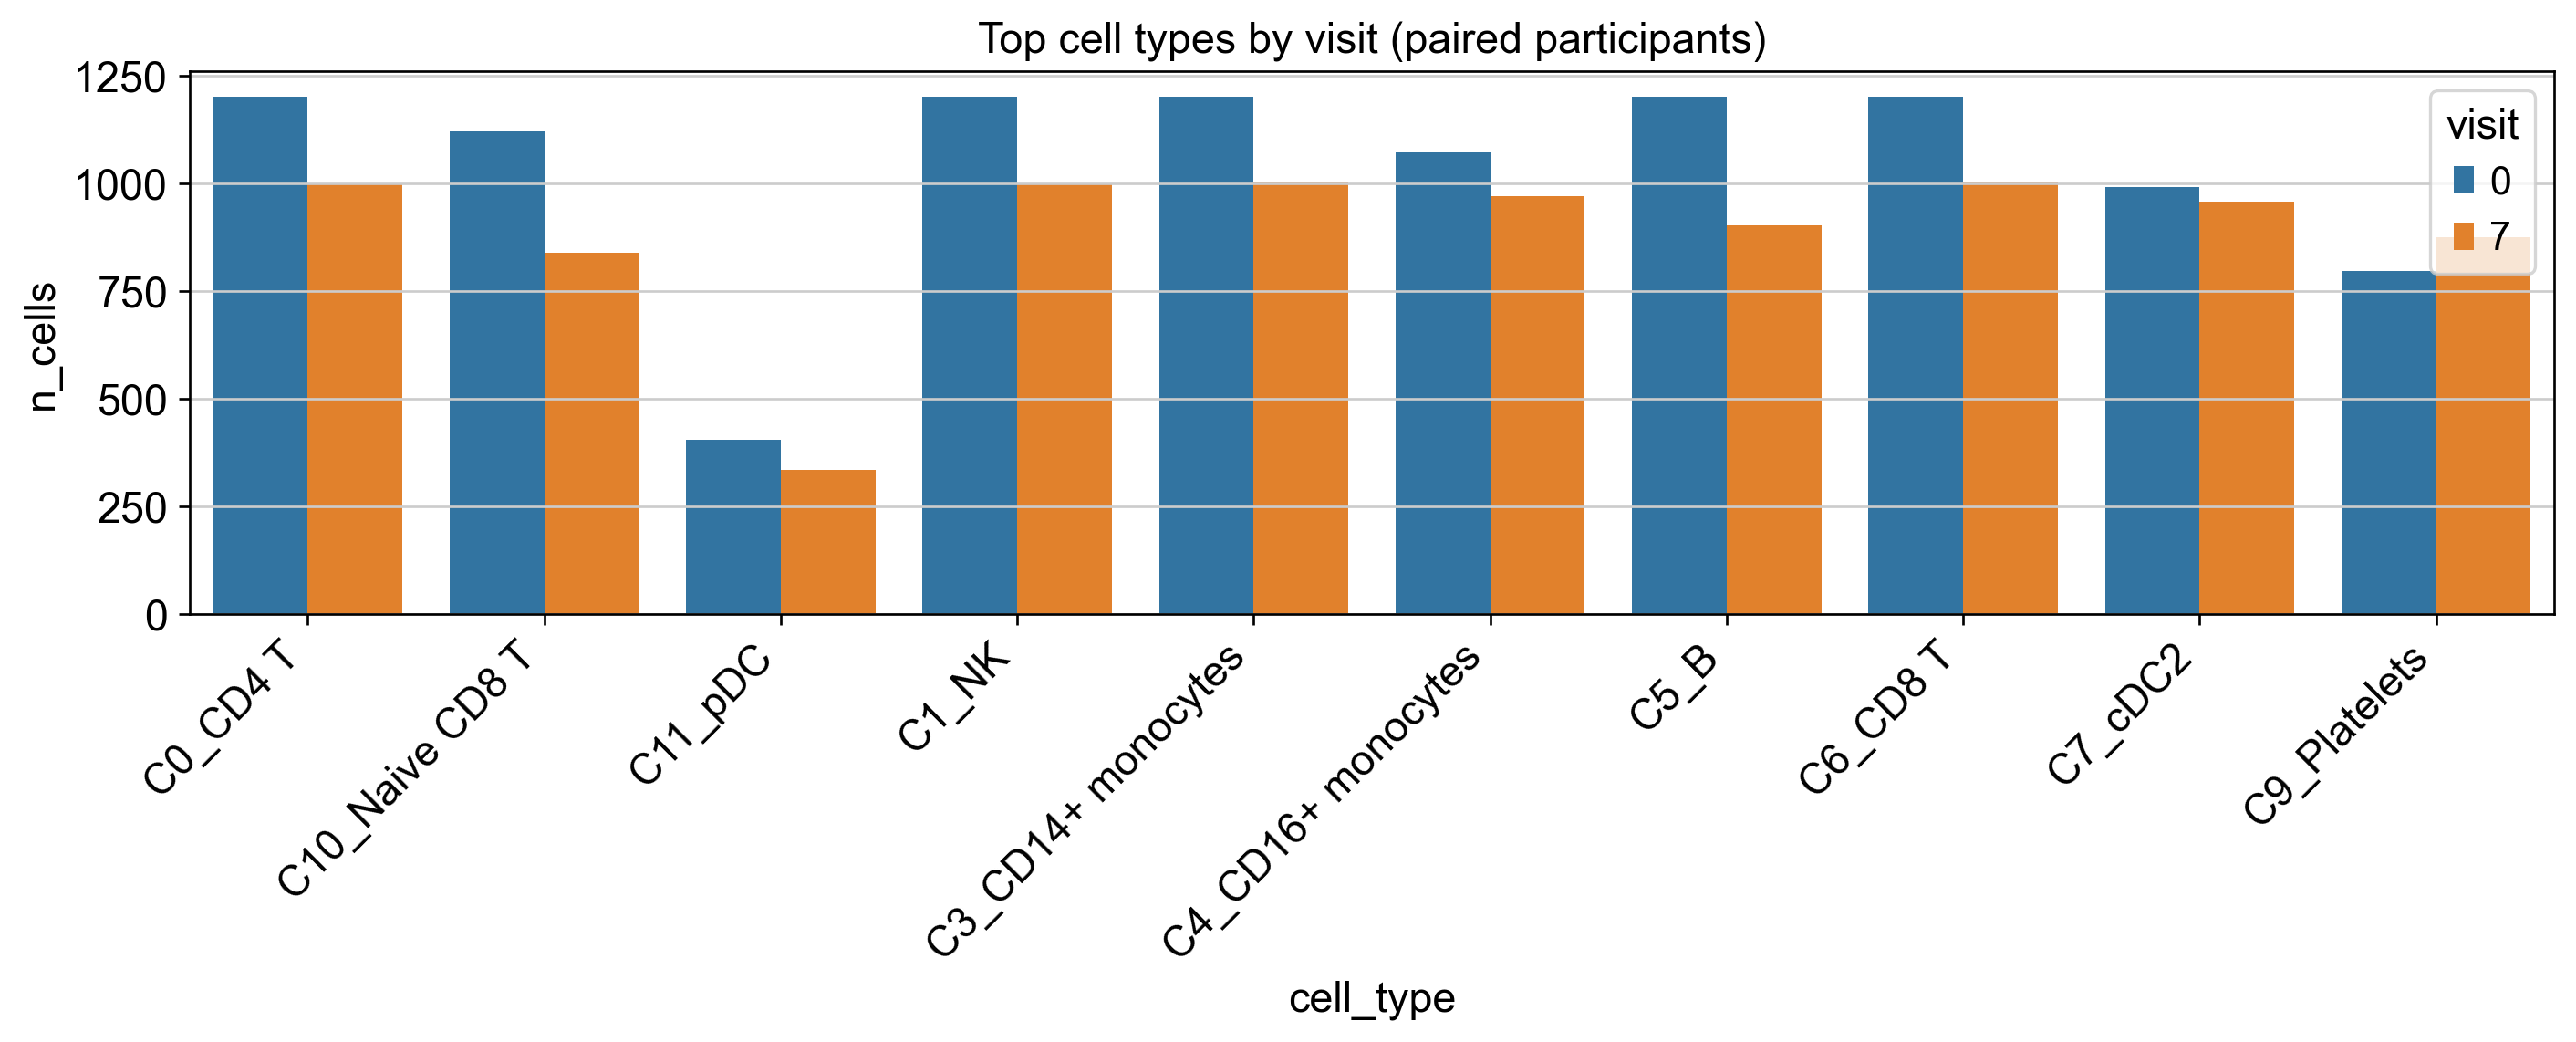

In [6]:
ct_visit = (
    adata_analysis.obs
    .groupby([design.celltype_col, design.visit_col], observed=True)
    .size()
    .reset_index(name="n_cells")
)

top_ct = adata_analysis.obs[design.celltype_col].value_counts().head(10).index
ct_visit_top = ct_visit[ct_visit[design.celltype_col].isin(top_ct)].copy()

plt.figure(figsize=(12, 5))
sns.barplot(data=ct_visit_top, x=design.celltype_col, y="n_cells", hue=design.visit_col)
plt.title("Top cell types by visit (paired participants)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()


## 4. UMAPs of All Cell Types

Here, we explore global structure across all cell types to understand broad immune landscape changes.


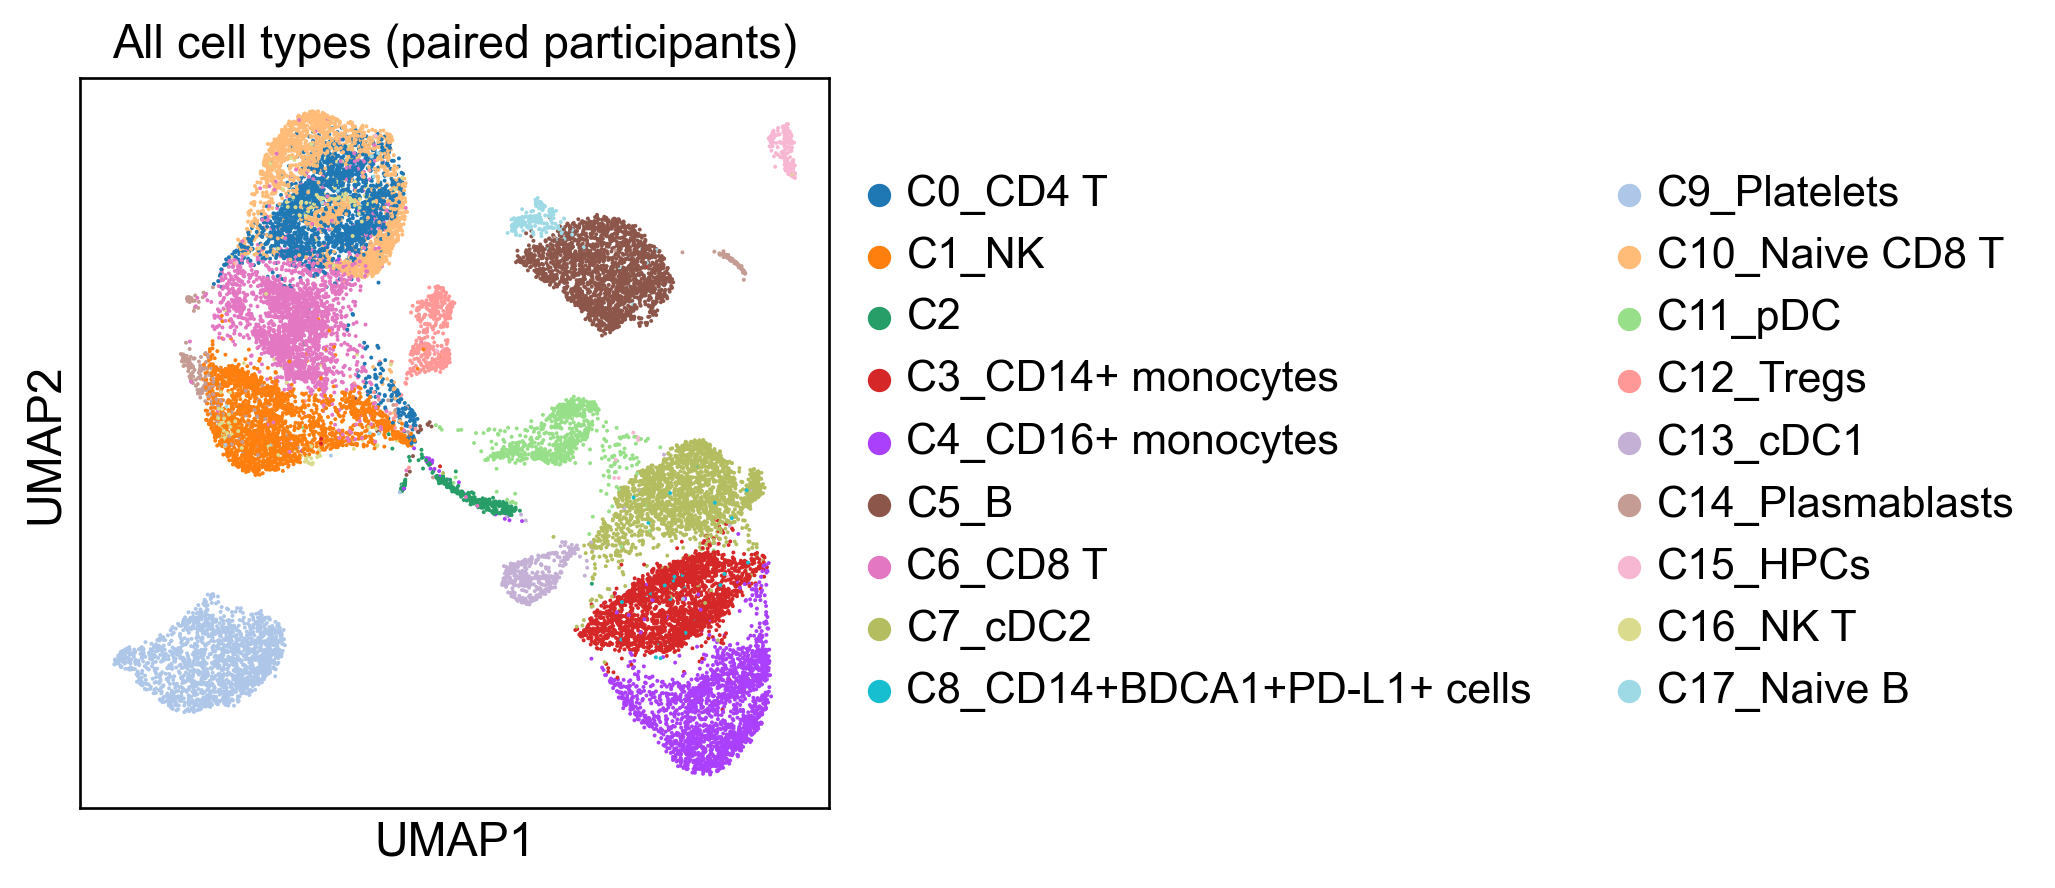

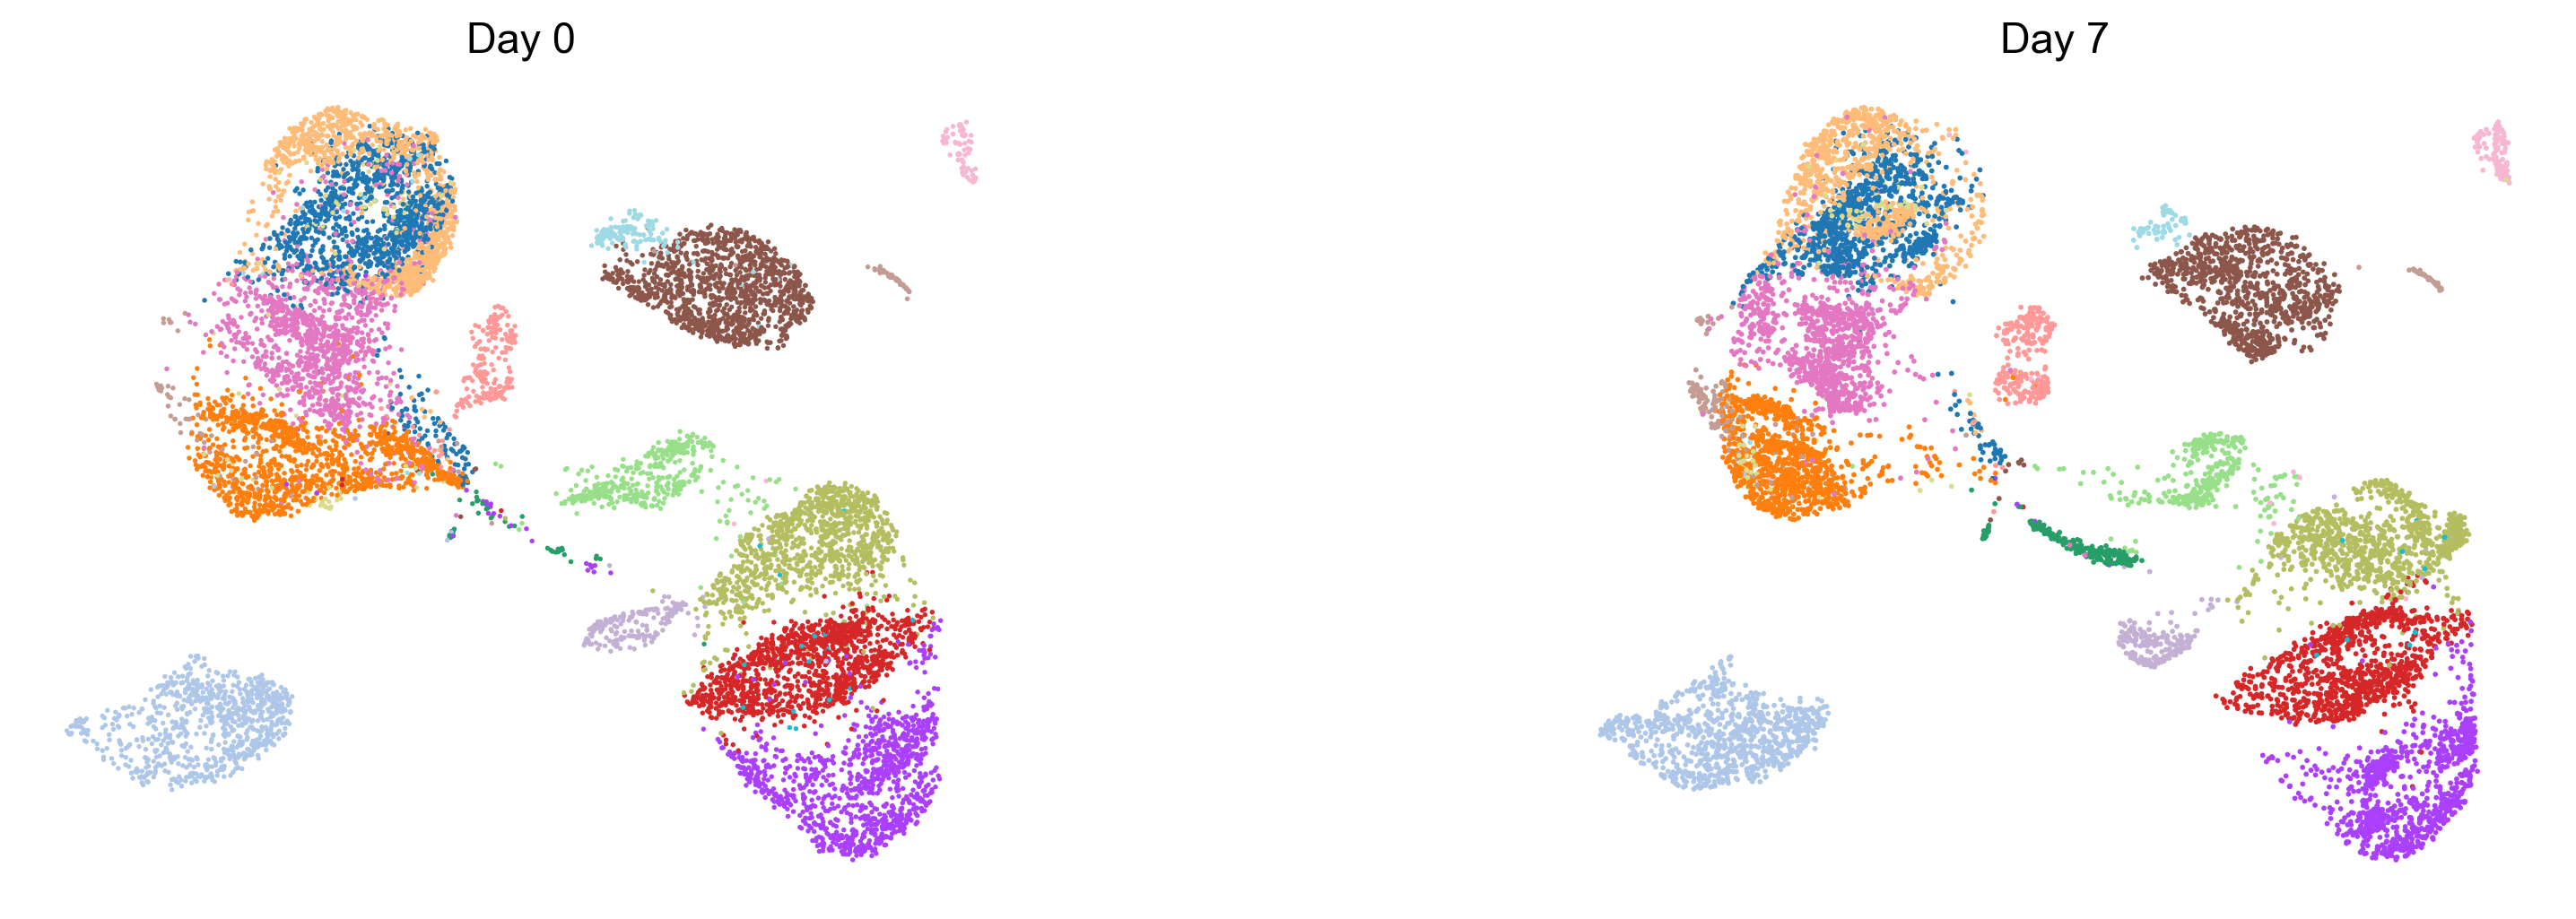

In [7]:
# Compute UMAP on log1p CPM if missing
adata_umap = adata_analysis.copy()
adata_umap.X = adata_umap.layers["log1p_cpm"].copy()

if "X_umap" not in adata_umap.obsm:
    sc.pp.pca(adata_umap)
    sc.pp.neighbors(adata_umap)
    sc.tl.umap(adata_umap)

sc.pl.umap(
    adata_umap,
    color=design.celltype_col,
    legend_loc="right margin",
    title="All cell types (paired participants)",
)

# Stratified UMAPs by visit
fig, axes = plt.subplots(1, len(visits), figsize=(16, 4.5))
if len(visits) == 1:
    axes = [axes]
for i, vis in enumerate(visits):
    sub = adata_umap[adata_umap.obs[design.visit_col] == vis].copy()
    ax = axes[i]
    if sub.n_obs > 0:
        sc.pl.umap(sub, color=design.celltype_col, ax=ax, show=False, legend_loc=None, frameon=False)
        ax.set_title(f"Day {vis}")
        ax.set_aspect('equal')
    else:
        ax.set_axis_off()
plt.tight_layout(); plt.show()


## 5. Module Scoring and Gene Panel

Here, we define biologically motivated signatures and a focused gene panel for downstream within‑arm testing.


In [8]:
available = set(adata_analysis.var_names)

# Define immunologically relevant gene sets for vaccine response
# Expanded to include T cell responses which are critical for vaccine immunity
raw_gene_sets = {
    "B_Cell_Response": ["CD79A", "CD79B", "MS4A1", "MZB1", "XBP1", "JCHAIN", "IGHG1", "IGHA1"],
    "IFN_Signature": ["ISG15", "IFI6", "IFIT1", "IFIT3", "MX1", "STAT1", "OAS1", "IRF7"],
    "Inflammatory": ["S100A8", "S100A9", "LYZ", "VCAN", "IL1B", "CXCL8", "CCL2"],
    "T_Cell_Activation": ["CD69", "CD38", "HLA-DRA", "ICOS", "IL2RA", "TNFRSF9"],
    "Cytotoxic": ["GZMB", "GZMA", "PRF1", "GNLY", "NKG7", "IFNG"],
    "Memory_T": ["IL7R", "TCF7", "LEF1", "CCR7", "SELL", "CD27"],
}

print("Gene set coverage:")
filtered = {}
for name, genes in raw_gene_sets.items():
    present = [g for g in genes if g in available]
    pct = len(present) / len(genes) * 100 if genes else 0
    status = "OK" if len(present) >= MIN_GENES_FOR_SCORE else "SKIP"
    print(f"  {name}: {len(present)}/{len(genes)} genes ({pct:.0f}%) [{status}]")
    if len(present) >= MIN_GENES_FOR_SCORE:
        filtered[name] = present

if filtered:
    adata_analysis = st.score_gene_sets(
        adata_analysis, filtered, layer="log1p_cpm", method="zmean", prefix="ms_"
    )
    print(f"\nScored {len(filtered)} gene sets using zmean.")
else:
    print(f"\nNo gene sets matched (min_genes={MIN_GENES_FOR_SCORE}); skipping module scoring.")

features = [c for c in adata_analysis.obs.columns if c.startswith("ms_")]
print("Module score features:", features)

# Panel genes for individual gene analysis (expanded)
panel_genes_all = [
    # B cell
    "CD79A", "CD79B", "MS4A1", "MZB1", "XBP1",
    # IFN
    "ISG15", "IFI6", "IFIT1", "MX1",
    # Inflammatory
    "S100A8", "S100A9", "LYZ", "VCAN",
    # T cell activation
    "CD69", "CD38", "IL2RA",
    # Cytotoxic
    "GZMB", "PRF1", "NKG7",
]
panel_genes = [g for g in panel_genes_all if g in available]
missing_panel = [g for g in panel_genes_all if g not in available]
print("\nPanel genes (available):", panel_genes)
if missing_panel:
    print("Panel genes missing:", missing_panel)

Gene set coverage:
  B_Cell_Response: 8/8 genes (100%) [OK]
  IFN_Signature: 8/8 genes (100%) [OK]
  Inflammatory: 7/7 genes (100%) [OK]
  T_Cell_Activation: 6/6 genes (100%) [OK]
  Cytotoxic: 6/6 genes (100%) [OK]
  Memory_T: 6/6 genes (100%) [OK]

Scored 6 gene sets using zmean.
Module score features: ['ms_B_Cell_Response', 'ms_IFN_Signature', 'ms_Inflammatory', 'ms_T_Cell_Activation', 'ms_Cytotoxic', 'ms_Memory_T']

Panel genes (available): ['CD79A', 'CD79B', 'MS4A1', 'MZB1', 'XBP1', 'ISG15', 'IFI6', 'IFIT1', 'MX1', 'S100A8', 'S100A9', 'LYZ', 'VCAN', 'CD69', 'CD38', 'IL2RA', 'GZMB', 'PRF1', 'NKG7']


In [9]:
# ============================================================================
# PAIRING VERIFICATION (package helper)
# ============================================================================
print("=" * 60)
print("PAIRING VERIFICATION (based on valid signature scores)")
print("=" * 60)

paired_info = verify_paired_participants(
    adata_analysis.obs,
    visit_col=visit_col,
    visits=visits,
    features=features,
    participant_col="participant_id",
)

VALID_PAIRED_IDS = paired_info["paired_ids"]
N_VALID_PAIRED = paired_info["n_paired"]

print("")
print(f"Participants with valid Day0+Day7 scores for ALL features: {N_VALID_PAIRED}")
print(f"Total participants: {paired_info['n_total']}")

if paired_info["dropped_ids"]:
    print(f"Dropped (missing visit or NaN features): {len(paired_info['dropped_ids'])}")
else:
    print("All paired participants have valid scores ✓")

print("")
print(f"Using {N_VALID_PAIRED} validated paired participants for analyses.")


PAIRING VERIFICATION (based on valid signature scores)

Participants with valid Day0+Day7 scores for ALL features: 6
Total participants: 6
All paired participants have valid scores ✓

Using 6 validated paired participants for analyses.


## 6. Within-Arm Comparisons (Participant-Level)

Here, we run paired within‑participant analyses to determine which module scores change from Day 0 to Day 7.


WITHIN-ARM COMPARISONS: MODULE SCORES (Day 0 vs Day 7)


,feature,beta_time,p_time,FDR_time,n_units
0,ms_B_Cell_Response,0.1108,0.9012,0.9060,6
1,ms_IFN_Signature,0.6007,0.3358,0.6717,6
2,ms_Inflammatory,-0.1222,0.9060,0.9060,6
3,ms_T_Cell_Activation,0.7555,0.2599,0.6717,6
4,ms_Cytotoxic,0.9041,0.3215,0.6717,6
5,ms_Memory_T,-0.4674,0.6293,0.9060,6



No module scores reached FDR < 0.25.

Boxplots show participant-level distributions by day; points indicate individual participants.


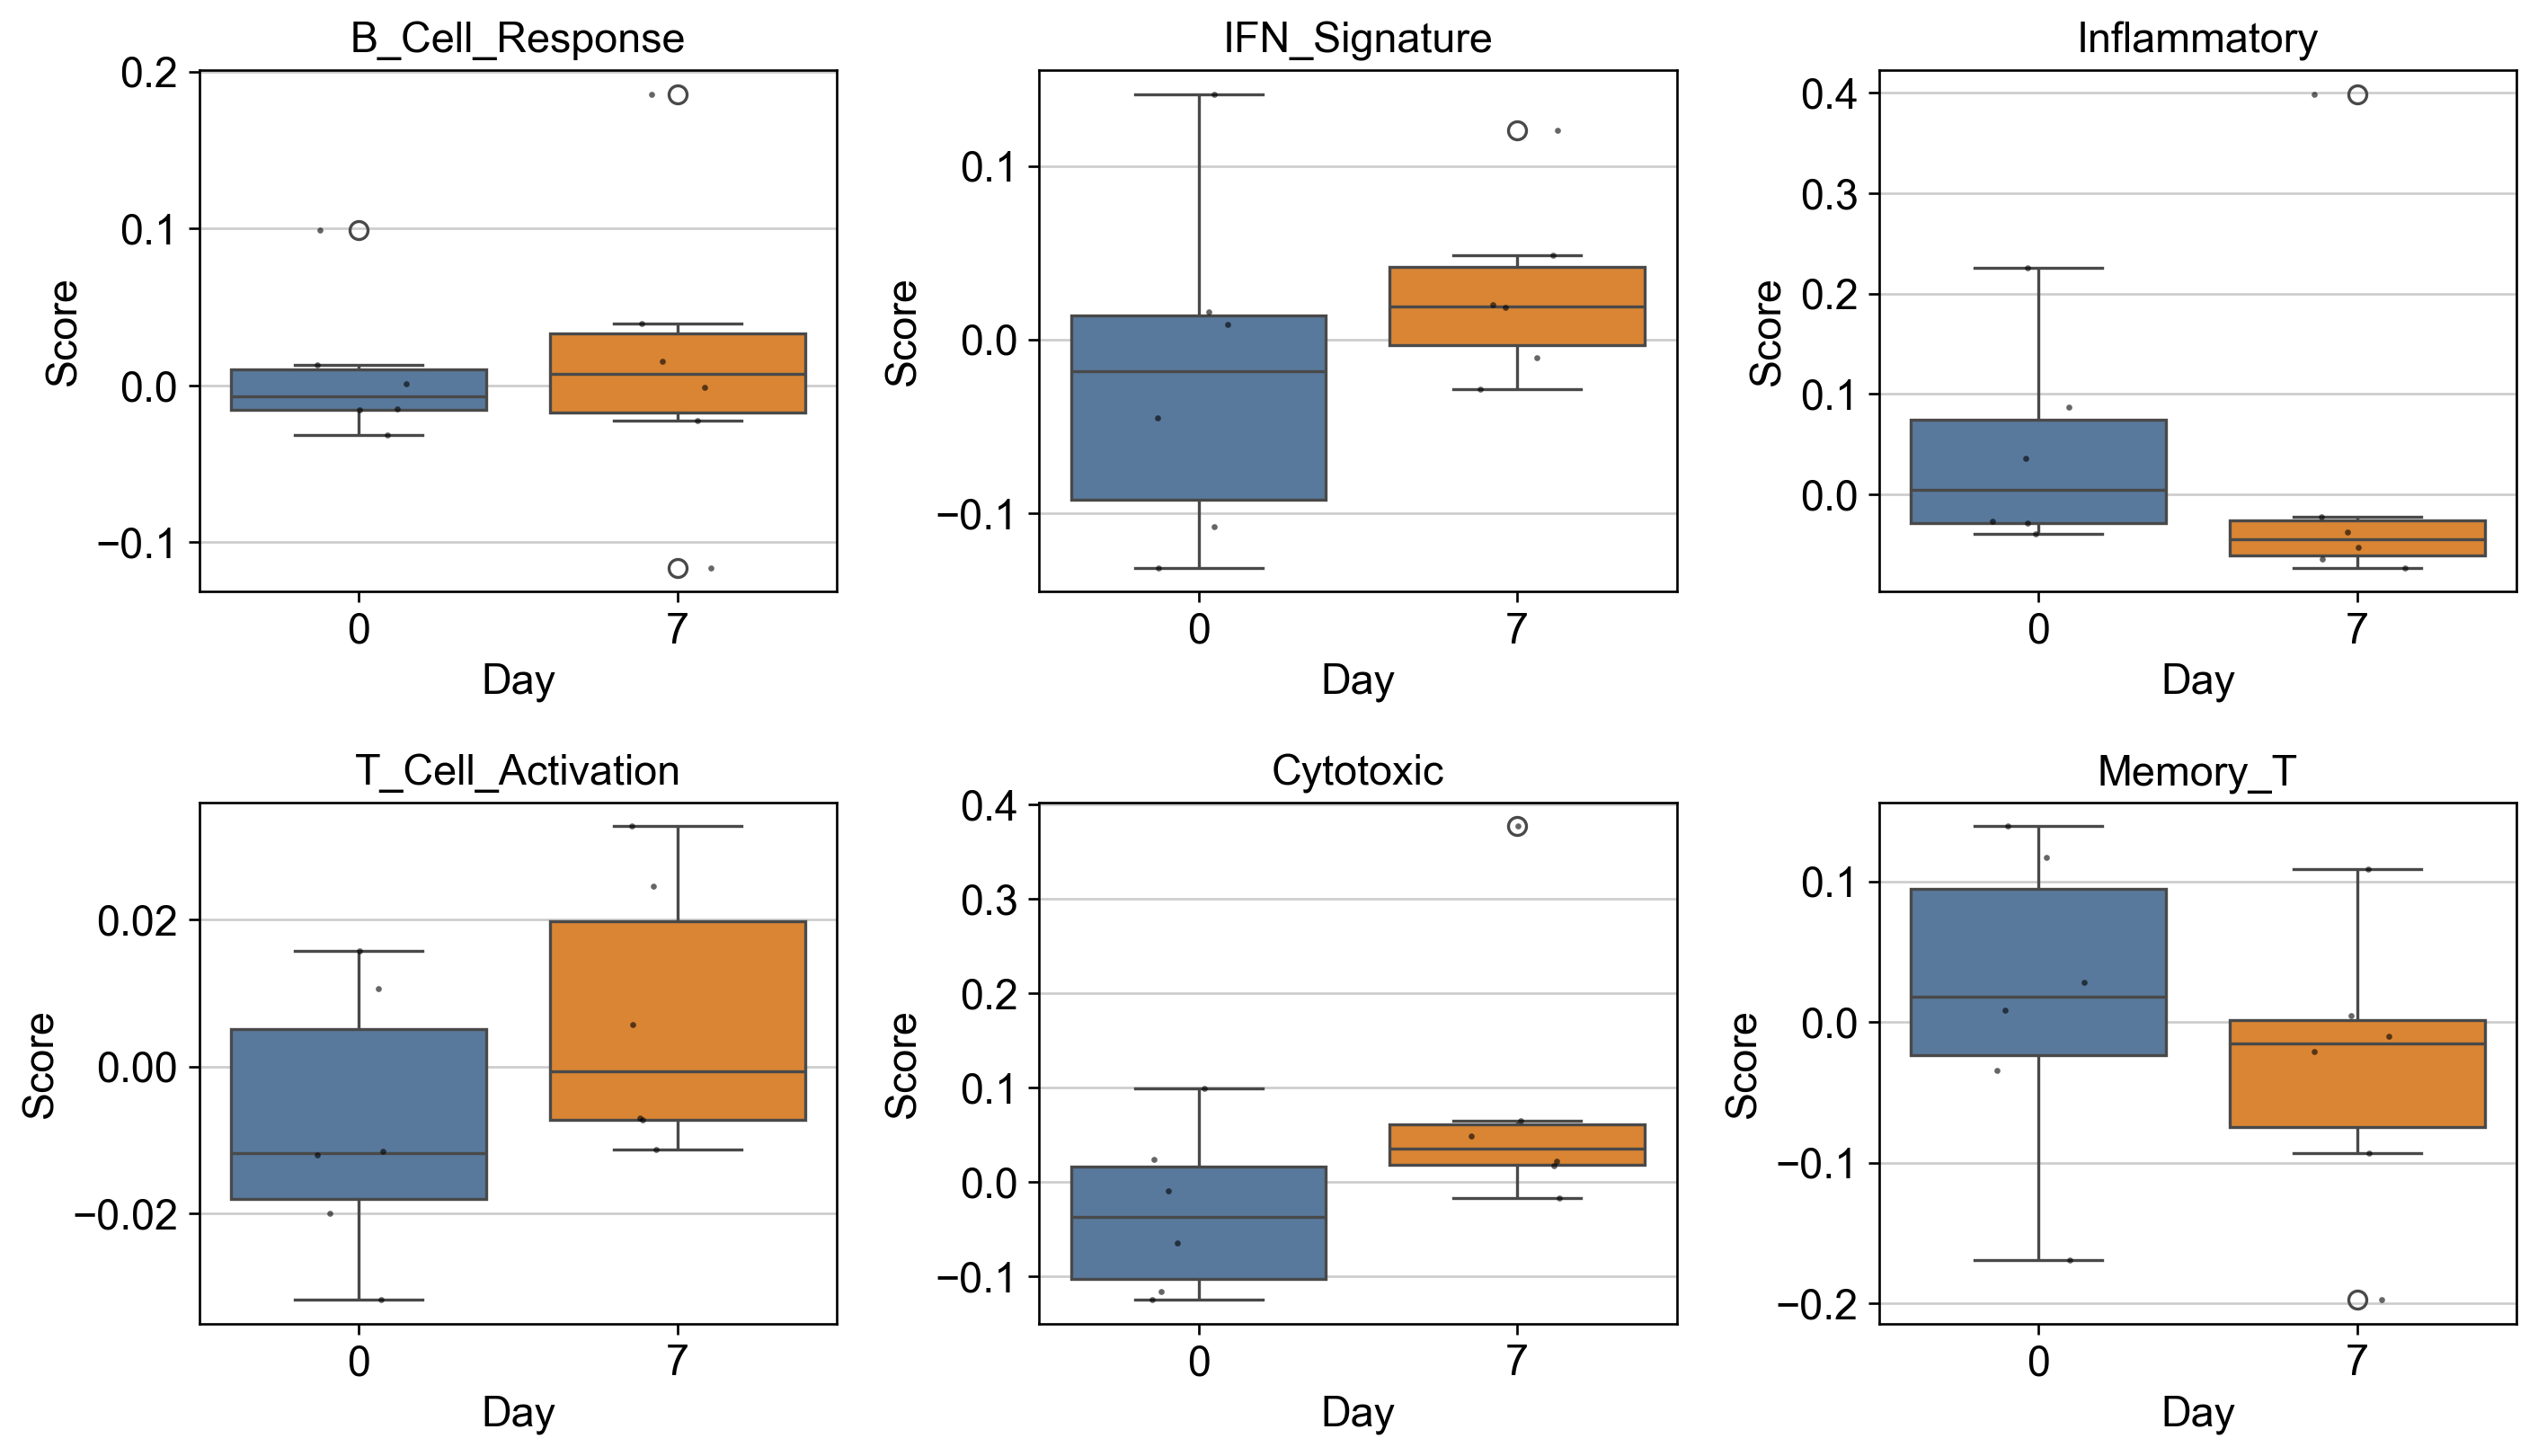

In [10]:
print("=" * 60)
print("WITHIN-ARM COMPARISONS: MODULE SCORES (Day 0 vs Day 7)")
print("=" * 60)

res_within = pd.DataFrame()
if features and len(visits) == 2:
    ad_sub = adata_analysis[adata_analysis.obs["participant_id"].isin(VALID_PAIRED_IDS)].copy()
    res_within = st.within_arm_comparison(
        ad_sub,
        arm="Vaccinated",
        features=features,
        design=design,
        visits=tuple(visits),
        aggregate="participant_visit",
        standardize=True,
    )

    if res_within is not None and not res_within.empty:
        if "FDR_time" not in res_within.columns and "p_time" in res_within.columns:
            mask = res_within["p_time"].notna()
            res_within["FDR_time"] = np.nan
            if mask.sum() > 0:
                res_within.loc[mask, "FDR_time"] = multipletests(
                    res_within.loc[mask, "p_time"], method="fdr_bh"
                )[1]
        display_cols = ["feature", "beta_time", "p_time", "FDR_time", "n_units"]
        display_cols = [c for c in display_cols if c in res_within.columns]
        display(res_within[display_cols].round(4))

        sig = res_within[(res_within["FDR_time"].notna()) & (res_within["FDR_time"] < FDR_ALPHA)]
        if not sig.empty:
            print("")
            print(f"Module score changes (FDR < {FDR_ALPHA}):")
            for _, row in sig.iterrows():
                direction = "increased" if row["beta_time"] > 0 else "decreased"
                print(f"  {row['feature']}: {direction} (β={row['beta_time']:.3f}, FDR={row['FDR_time']:.3f})")
        else:
            print("")
            print(f"No module scores reached FDR < {FDR_ALPHA}.")
    else:
        print("No within-arm results for module scores.")
else:
    print("Insufficient features or visits for within-arm comparisons.")

print("")
print("Boxplots show participant-level distributions by day; points indicate individual participants.")

# Plot participant-level module scores by day
if features and len(visits) == 2:
    df_plot = (
        adata_analysis.obs
        .groupby(["participant_id", "visit"], observed=True)[features]
        .mean()
        .reset_index()
    )

    n_feats = len(features)
    n_cols = min(3, n_feats)
    n_rows = (n_feats + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
    axes = np.array(axes).reshape(-1)

    for i, feat in enumerate(features):
        ax = axes[i]
        sns.boxplot(
            data=df_plot,
            x="visit",
            y=feat,
            hue="visit",
            ax=ax,
            order=visits,
            palette={"0": "#4C78A8", "7": "#F58518"},
            dodge=False,
            linewidth=1,
        )
        sns.stripplot(
            data=df_plot,
            x="visit",
            y=feat,
            ax=ax,
            order=visits,
            color="black",
            size=2,
            alpha=0.6,
            jitter=0.15,
        )
        ax.set_title(feat.replace("ms_", ""))
        ax.set_xlabel("Day")
        ax.set_ylabel("Score")
        if ax.legend_:
            ax.legend_.remove()

    for j in range(i+1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


## 7. Gene Expression Within-Arm (Panel Genes)

Here, we test targeted panel genes for within‑arm changes using participant‑level aggregation.


WITHIN-ARM COMPARISONS: PANEL GENES (Day 0 vs Day 7)


,feature,beta_time,p_time,FDR_time,n_units
0,CD79A,-0.2122,0.8221,0.9581,6
1,CD79B,0.2711,0.8031,0.9581,6
2,MS4A1,-0.6702,0.3075,0.9581,6
3,MZB1,0.2472,0.7017,0.9581,6
4,XBP1,0.0470,0.9465,0.9581,6
5,ISG15,0.7015,0.4493,0.9581,6
6,IFI6,0.7143,0.0000,0.0000,6
7,IFIT1,0.3211,0.6061,0.9581,6
8,MX1,0.3230,0.4390,0.9581,6
9,S100A8,0.0531,0.9581,0.9581,6



Panel genes with significant changes (FDR < 0.25):
  IFI6: increased (β=0.714, FDR=0.000)

Boxplots show participant-level log1p CPM by day; points indicate individual participants.


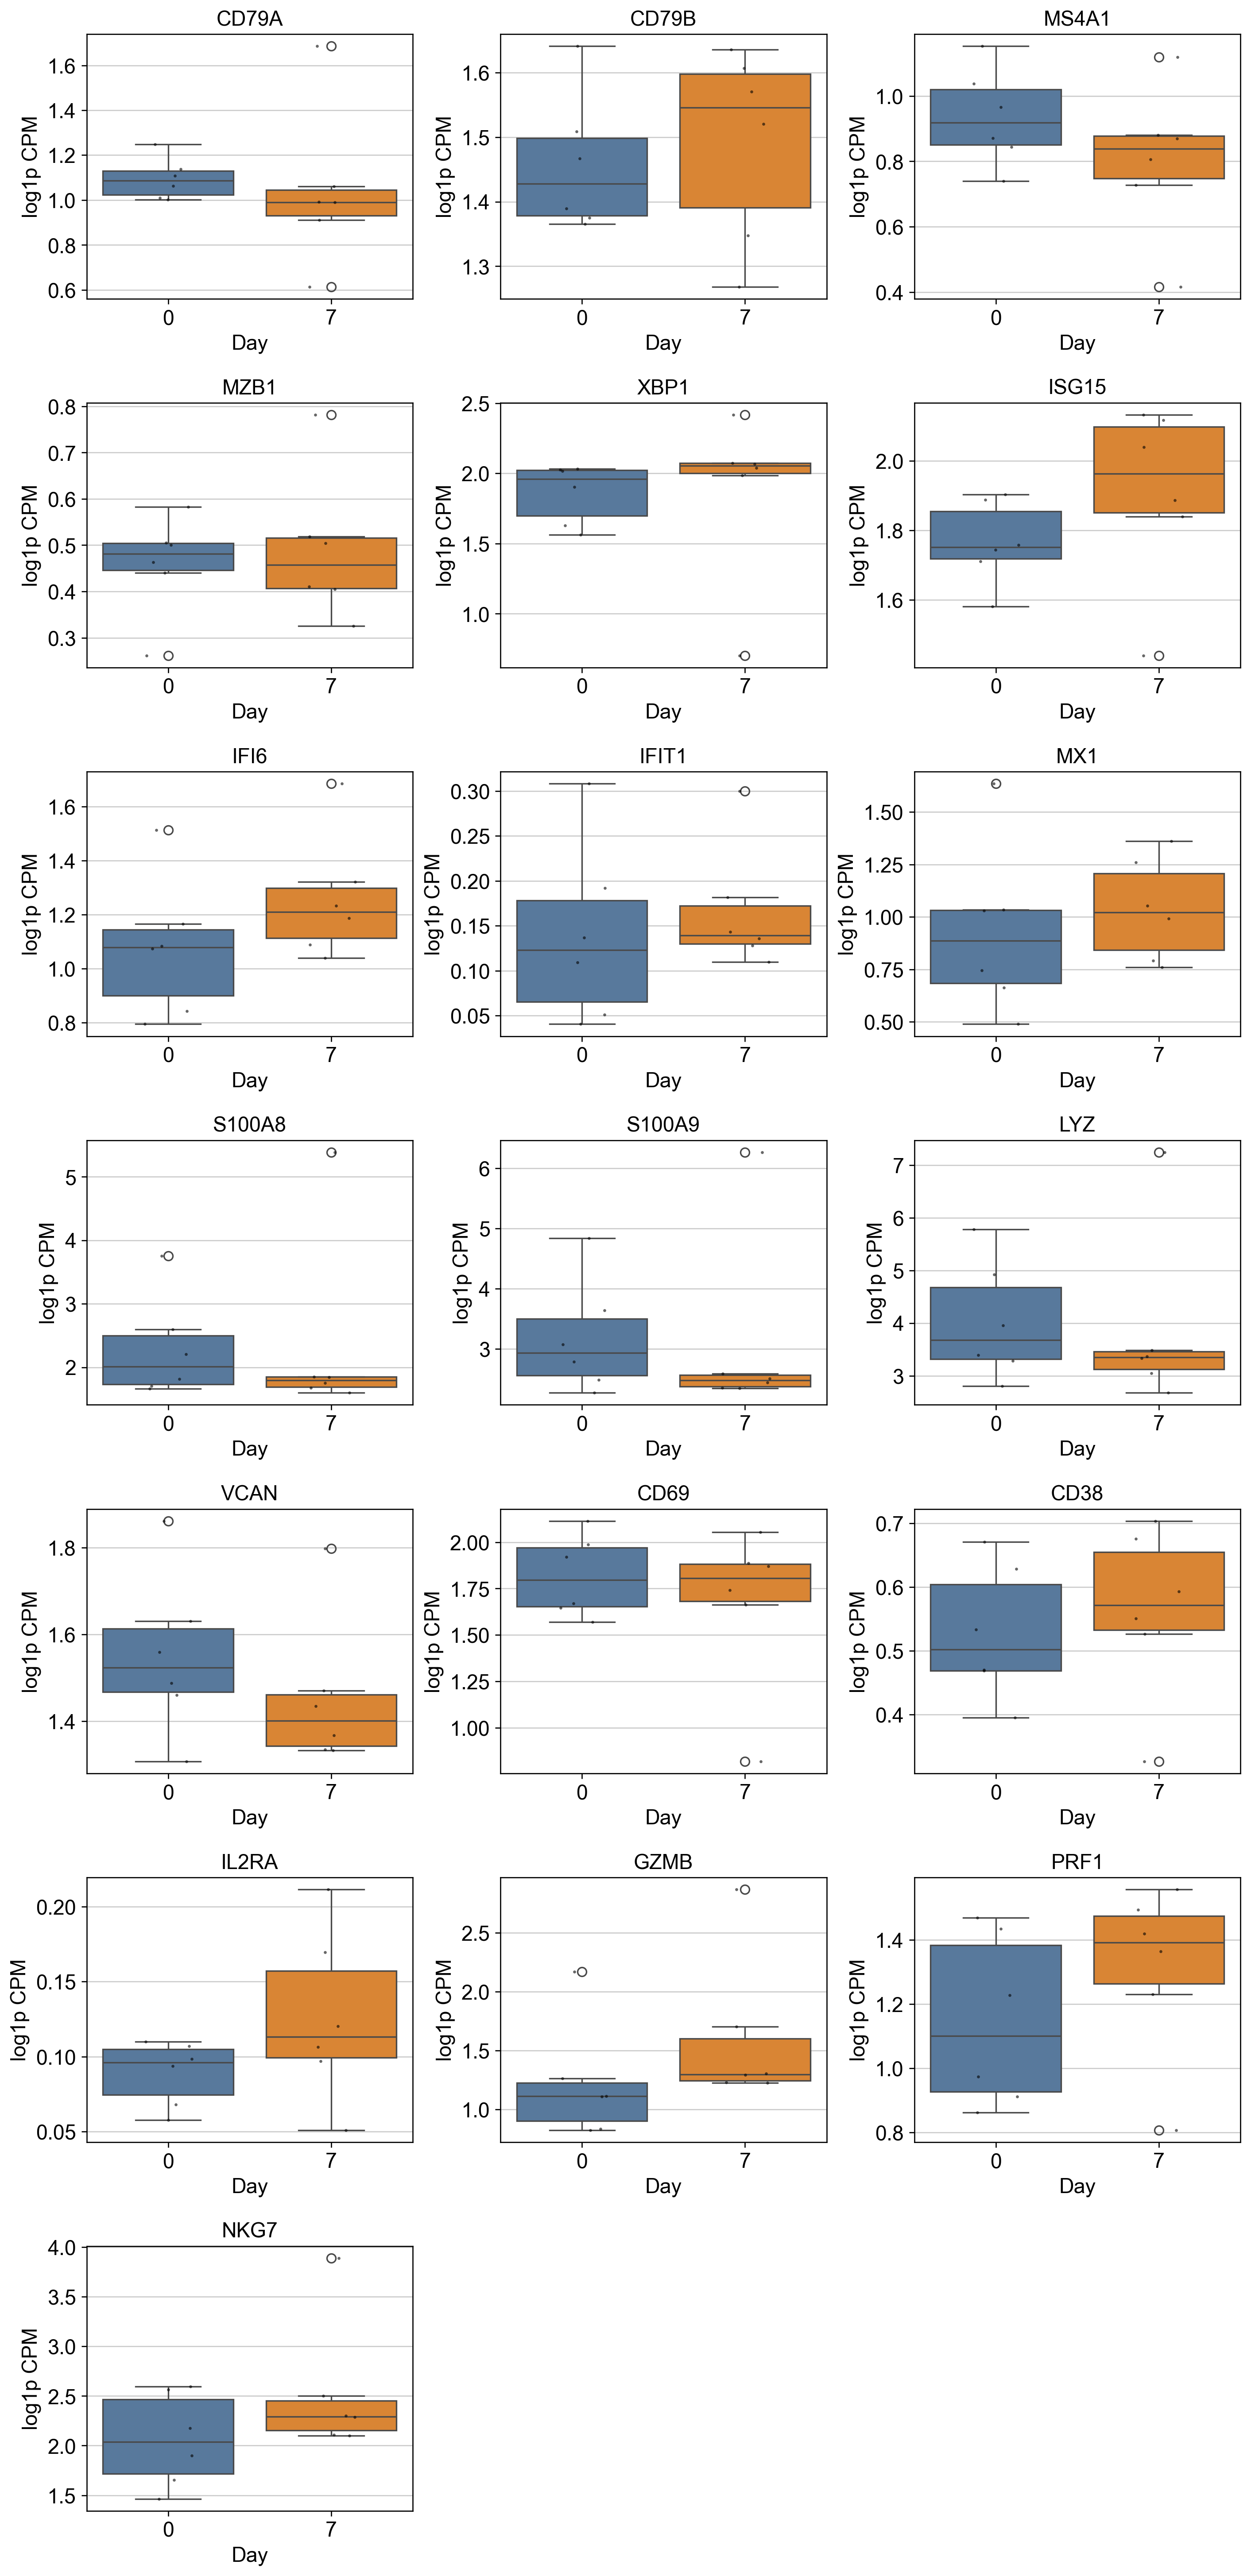

In [11]:
print("=" * 60)
print("WITHIN-ARM COMPARISONS: PANEL GENES (Day 0 vs Day 7)")
print("=" * 60)

res_genes = pd.DataFrame()
if panel_genes and len(visits) == 2:
    ad_sub = adata_analysis[adata_analysis.obs["participant_id"].isin(VALID_PAIRED_IDS)].copy()
    res_genes = st.within_arm_comparison(
        ad_sub,
        arm="Vaccinated",
        features=panel_genes,
        design=design,
        visits=tuple(visits),
        aggregate="participant_visit",
        standardize=True,
        layer="log1p_cpm",
    )

    if res_genes is not None and not res_genes.empty:
        if "FDR_time" not in res_genes.columns and "p_time" in res_genes.columns:
            mask = res_genes["p_time"].notna()
            res_genes["FDR_time"] = np.nan
            if mask.sum() > 0:
                res_genes.loc[mask, "FDR_time"] = multipletests(
                    res_genes.loc[mask, "p_time"], method="fdr_bh"
                )[1]
        display_cols = ["feature", "beta_time", "p_time", "FDR_time", "n_units"]
        display_cols = [c for c in display_cols if c in res_genes.columns]
        display(res_genes[display_cols].round(4))

        sig = res_genes[(res_genes["FDR_time"].notna()) & (res_genes["FDR_time"] < FDR_ALPHA)]
        if not sig.empty:
            print("")
            print(f"Panel genes with significant changes (FDR < {FDR_ALPHA}):")
            for _, row in sig.iterrows():
                direction = "increased" if row["beta_time"] > 0 else "decreased"
                print(f"  {row['feature']}: {direction} (β={row['beta_time']:.3f}, FDR={row['FDR_time']:.3f})")
        else:
            print("")
            print(f"No panel genes reached FDR < {FDR_ALPHA}.")
    else:
        print("No within-arm results for panel genes.")
else:
    print("No panel genes available or missing visits.")

print("")
print("Boxplots show participant-level log1p CPM by day; points indicate individual participants.")

# Plot participant-level panel genes by day (log1p CPM)
if panel_genes and len(visits) == 2:
    df_expr = adata_analysis.obs[["participant_id", "visit"]].copy()
    for g in panel_genes:
        df_expr[g] = st.extract_gene_vector(adata_analysis, g, layer="log1p_cpm")

    df_plot = (
        df_expr
        .groupby(["participant_id", "visit"], observed=True)[panel_genes]
        .mean()
        .reset_index()
    )

    n_feats = len(panel_genes)
    n_cols = min(3, n_feats)
    n_rows = (n_feats + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
    axes = np.array(axes).reshape(-1)

    for i, feat in enumerate(panel_genes):
        ax = axes[i]
        sns.boxplot(
            data=df_plot,
            x="visit",
            y=feat,
            hue="visit",
            ax=ax,
            order=visits,
            palette={"0": "#4C78A8", "7": "#F58518"},
            dodge=False,
            linewidth=1,
        )
        sns.stripplot(
            data=df_plot,
            x="visit",
            y=feat,
            ax=ax,
            order=visits,
            color="black",
            size=2,
            alpha=0.6,
            jitter=0.15,
        )
        ax.set_title(feat)
        ax.set_xlabel("Day")
        ax.set_ylabel("log1p CPM")
        if ax.legend_:
            ax.legend_.remove()

    for j in range(i+1, len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()


## 8. Pseudobulk Within-Arm (Panel Genes)

Here, we aggregate counts to pseudobulk profiles and quantify gene‑level shifts by cell type.


Pseudobulk paired deltas with Wilcoxon signed-rank test (panel genes × cell type):


,celltype,feature,n_units,mean_delta,median_delta,p_time,FDR_time
217,C3_CD14+ monocytes,MX1,6,0.376383,0.397559,0.03125,0.363153
222,C3_CD14+ monocytes,CD69,6,-1.000836,-0.699824,0.03125,0.363153
284,C6_CD8 T,NKG7,6,0.406716,0.355028,0.03125,0.363153
278,C6_CD8 T,VCAN,6,-0.986688,-0.894316,0.03125,0.363153
283,C6_CD8 T,PRF1,6,0.662143,0.633262,0.03125,0.363153
188,C1_NK,PRF1,5,0.300962,0.254804,0.06250,0.363153
225,C3_CD14+ monocytes,GZMB,6,-0.894293,-1.008885,0.06250,0.363153
189,C1_NK,NKG7,5,0.334008,0.208272,0.06250,0.363153
256,C5_B,S100A8,5,-1.368936,-1.233742,0.06250,0.363153
257,C5_B,S100A9,5,-1.506106,-1.401379,0.06250,0.363153


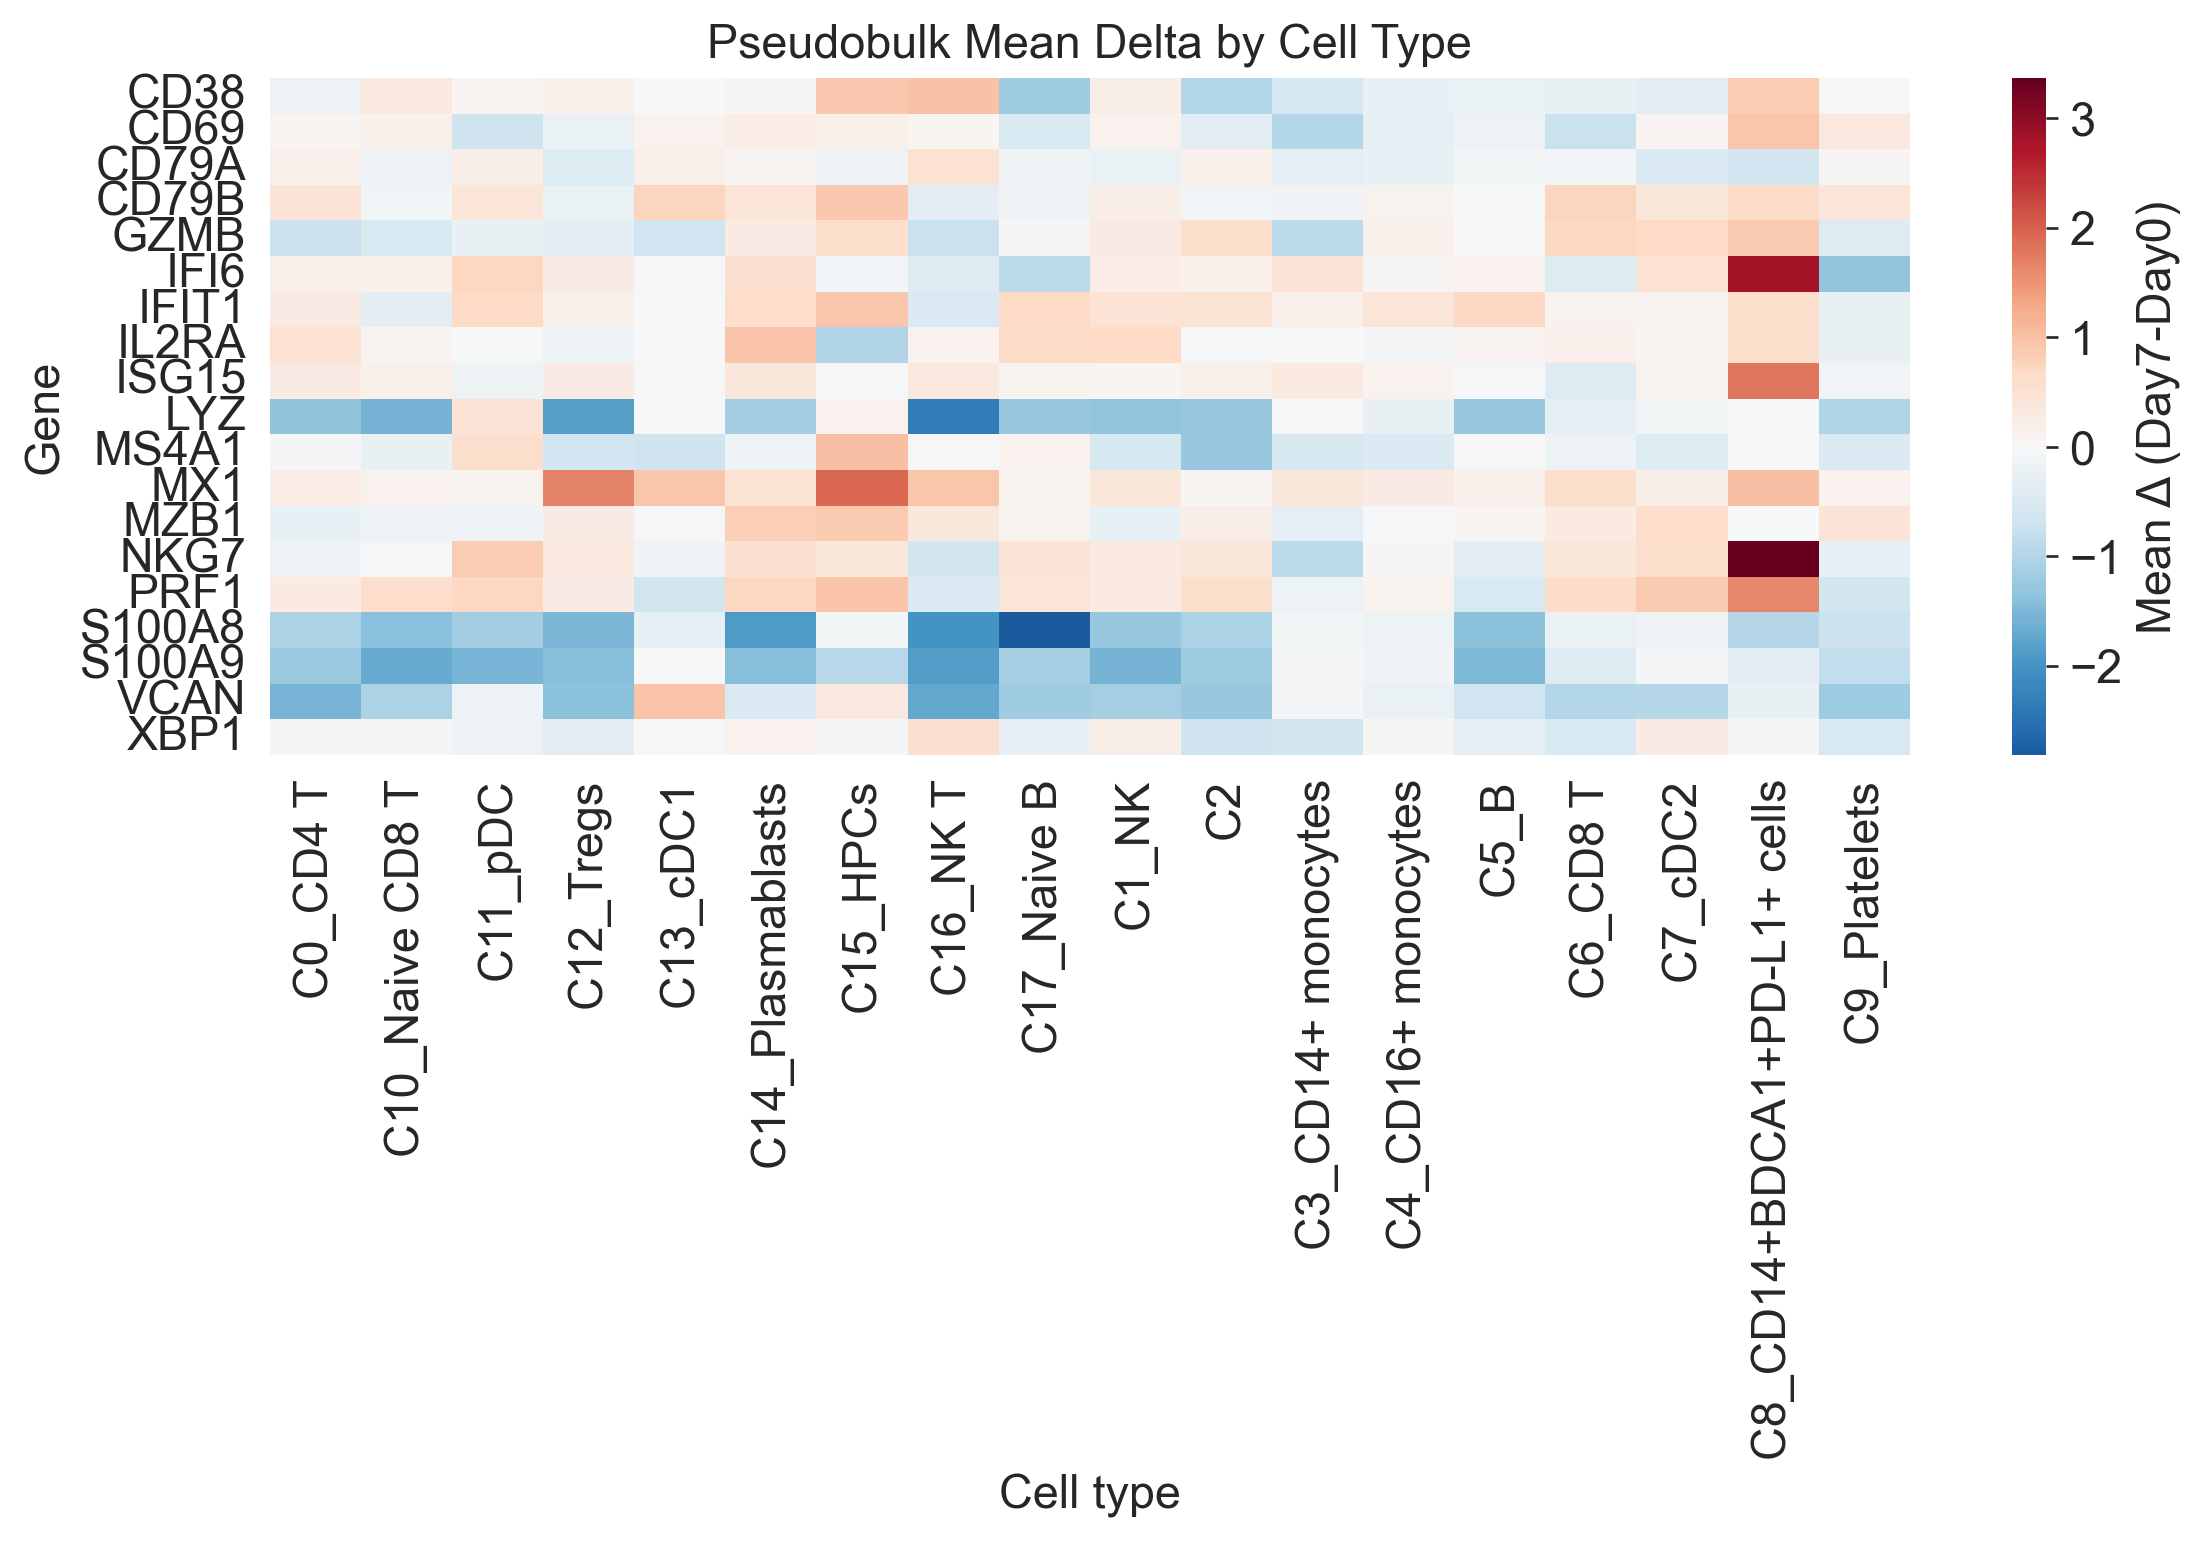

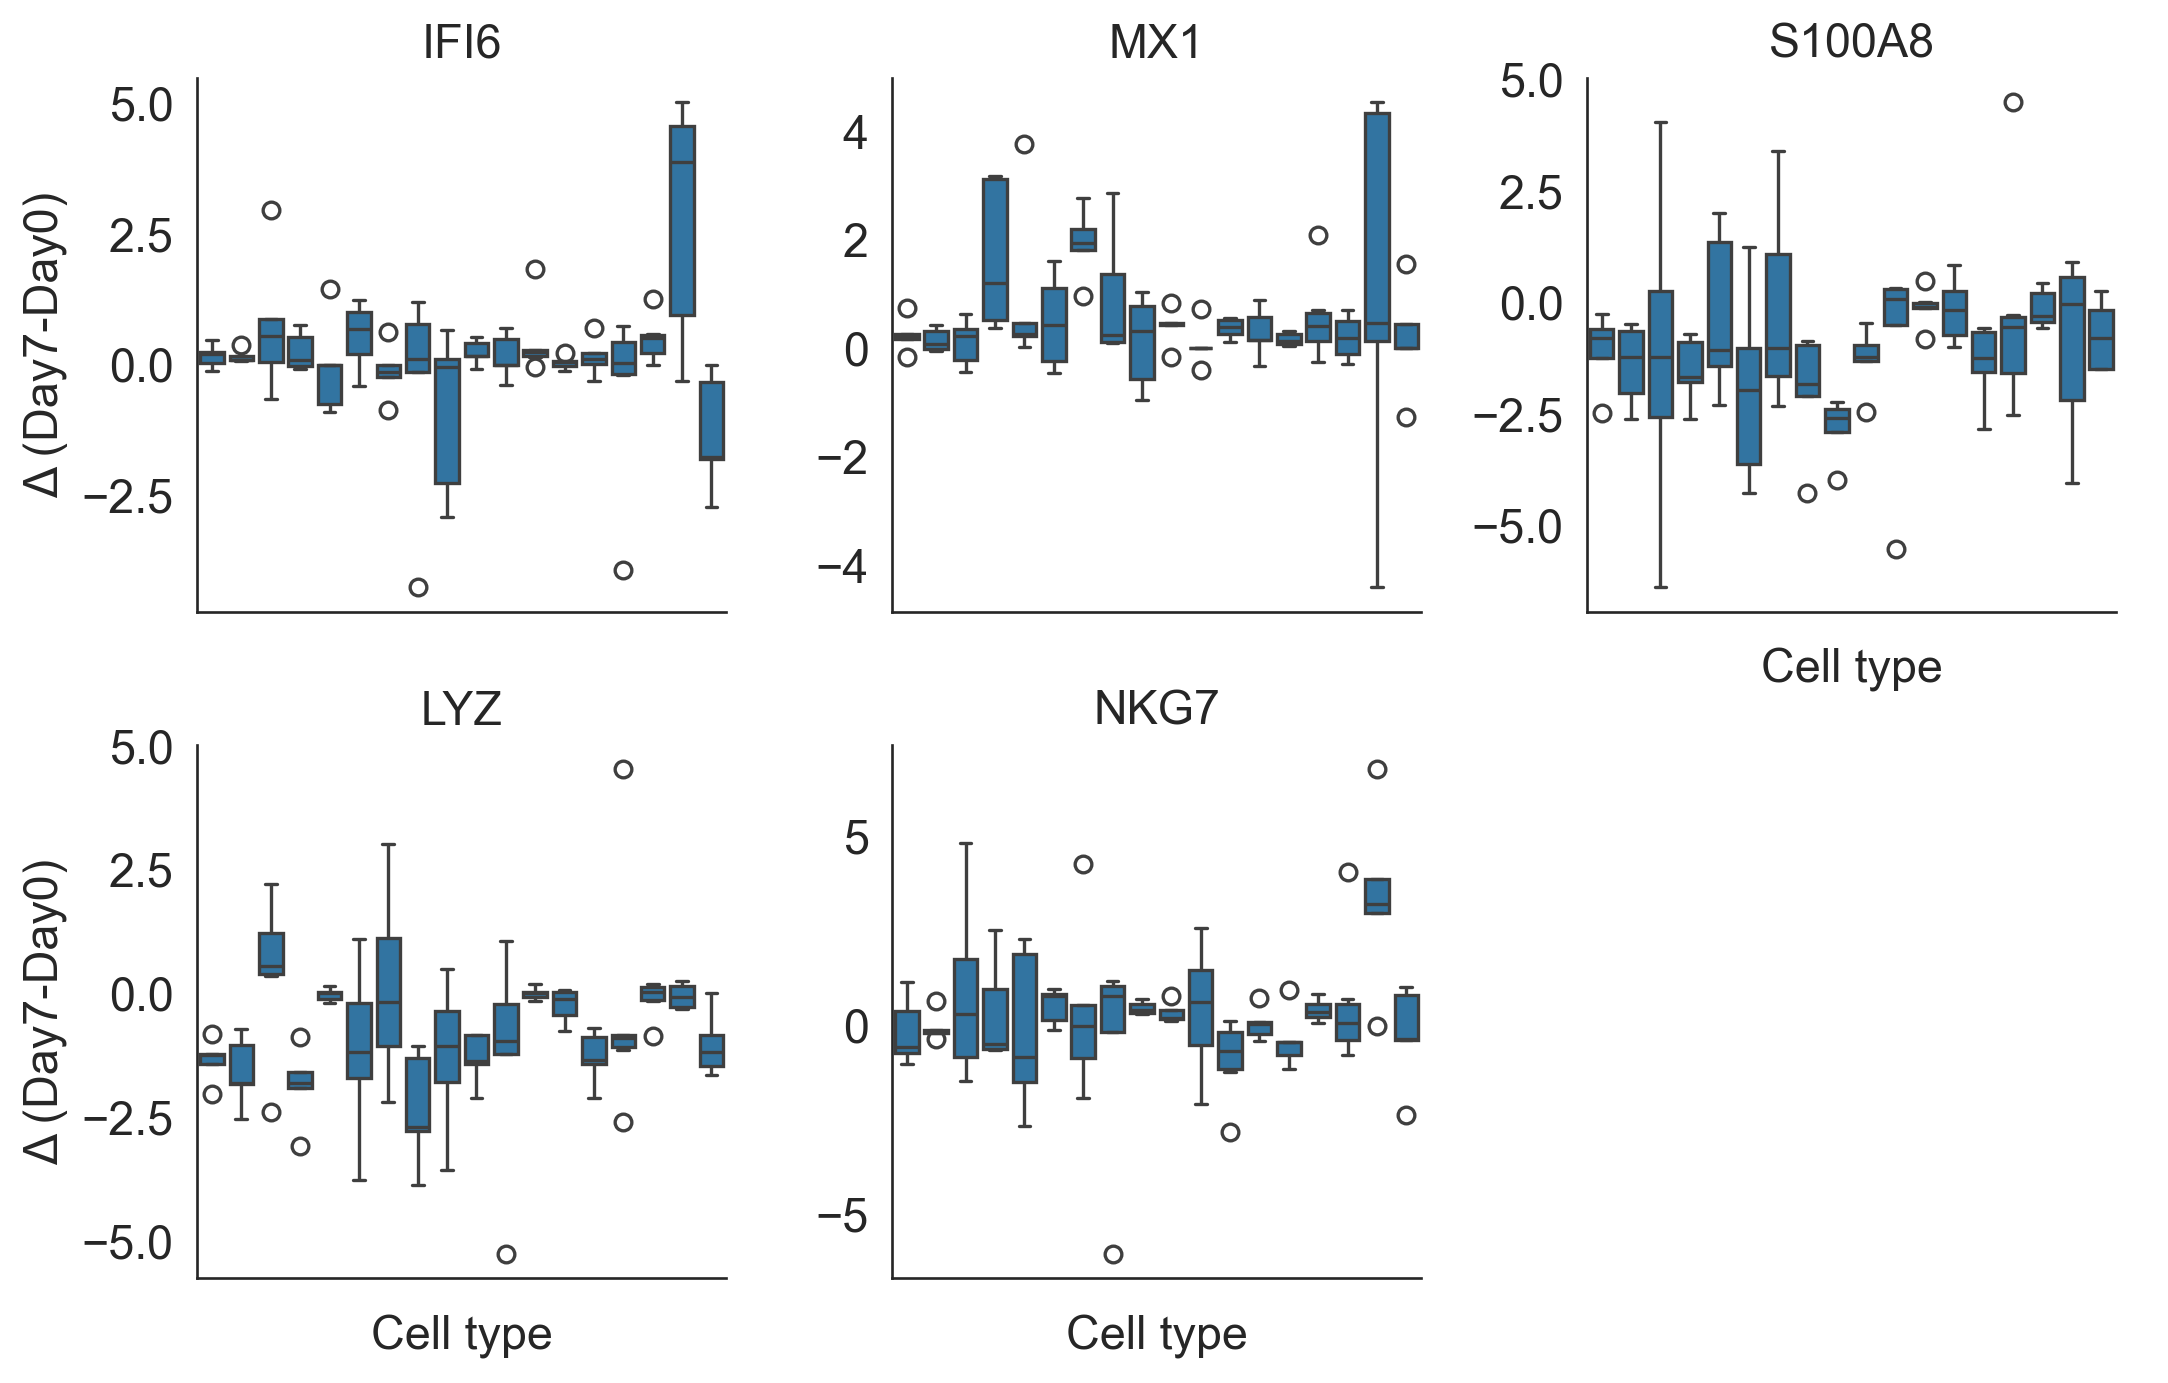

In [12]:
from scipy.stats import wilcoxon

if panel_genes and n_paired >= MIN_PAIRED and len(visits) == 2:
    # Use package helper for pseudobulk within-arm analysis
    pb, pb_deltas = st.pseudobulk_within_arm(
        adata_analysis,
        genes=panel_genes,
        participant_col="participant_id",
        visit_col=design.visit_col,
        visits=visits,
        celltype_col=design.celltype_col,
        counts_layer="counts",
        min_paired=MIN_PAIRED,
    )

    if not pb.empty:
        print("Pseudobulk paired deltas with Wilcoxon signed-rank test (panel genes × cell type):")
        display(pb.sort_values(["p_time"]).head(30))

        sig = pb[(pb["FDR_time"].notna()) & (pb["FDR_time"] < FDR_ALPHA)]
        if not sig.empty:
            print("")
            print(f"Significant pseudobulk changes (FDR < {FDR_ALPHA}):")
            for _, row in sig.iterrows():
                direction = "↑" if row["mean_delta"] > 0 else "↓"
                print(f"  {row['celltype']} - {row['feature']}: {direction} (delta={row['mean_delta']:.3f}, FDR={row['FDR_time']:.3f})")
    else:
        print("No pseudobulk results generated.")

    # Pseudobulk heatmap (mean delta by cell type × gene)
    if not pb.empty:
        sns.set_style("white")
        pivot = pb.pivot(index="feature", columns="celltype", values="mean_delta")
        plt.figure(figsize=(10, max(4, 0.35*len(pivot))))
        ax = plt.gca()
        sns.heatmap(
            pivot,
            cmap="RdBu_r",
            center=0,
            cbar_kws={"label": "Mean Δ (Day7-Day0)"},
            linewidths=0,
            linecolor="none",
        )
        ax.grid(False)
        ax.set_axisbelow(False)
        plt.title("Pseudobulk Mean Delta by Cell Type")
        plt.xlabel("Cell type")
        plt.ylabel("Gene")
        plt.tight_layout()
        plt.show()

    # Distribution plots for top genes (by absolute mean delta)
    if not pb.empty and not pb_deltas.empty:
        top_genes = (
            pb.assign(abs_delta=pb["mean_delta"].abs())
            .sort_values("abs_delta", ascending=False)
            .head(6)["feature"].unique()
        )
        plot_df = pb_deltas[pb_deltas["feature"].isin(top_genes)].copy()
        if not plot_df.empty:
            g = sns.catplot(
                data=plot_df,
                x="celltype",
                y="delta",
                col="feature",
                kind="box",
                col_wrap=3,
                sharey=False,
                height=3,
            )
            g.set_titles("{col_name}")
            g.set_xticklabels(rotation=45, ha="right")
            g.set_axis_labels("Cell type", "Δ (Day7-Day0)")
            plt.tight_layout()
            plt.show()
else:
    print("Insufficient paired participants for pseudobulk.")


## 9. Trial Interaction Plot (Single Arm)

Here, we visualize paired trajectories to interpret direction and magnitude of change.


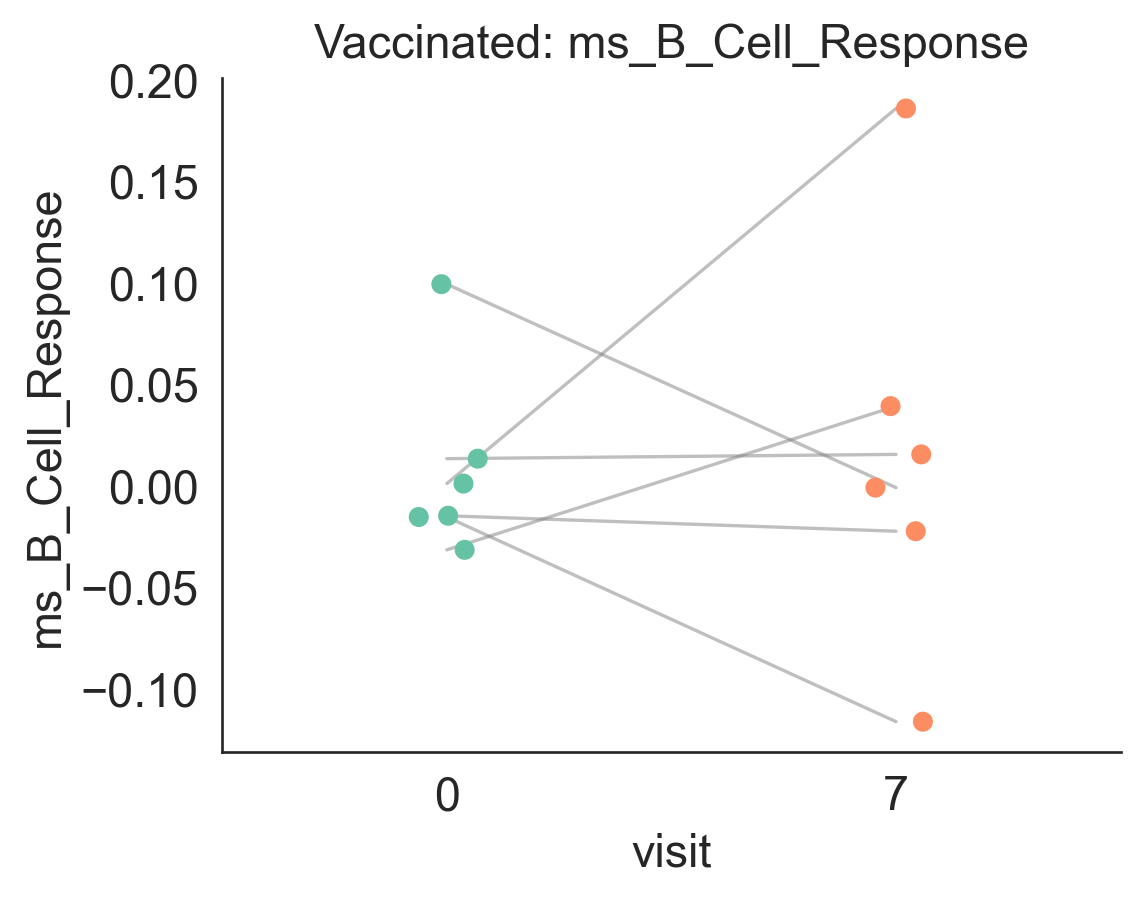

In [13]:
if features and len(visits) == 2:
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    st.plot_within_arm_comparison(
        adata_analysis,
        arm="Vaccinated",
        feature=features[0],
        design=design,
        visits=tuple(visits),
        plot_type="paired",
        ax=ax,
    )
    plt.tight_layout(); plt.show()


## 10. Trial UMAP Panel for a Module Score

Here, we overlay a module score on the UMAP to localize signal to specific cell populations.


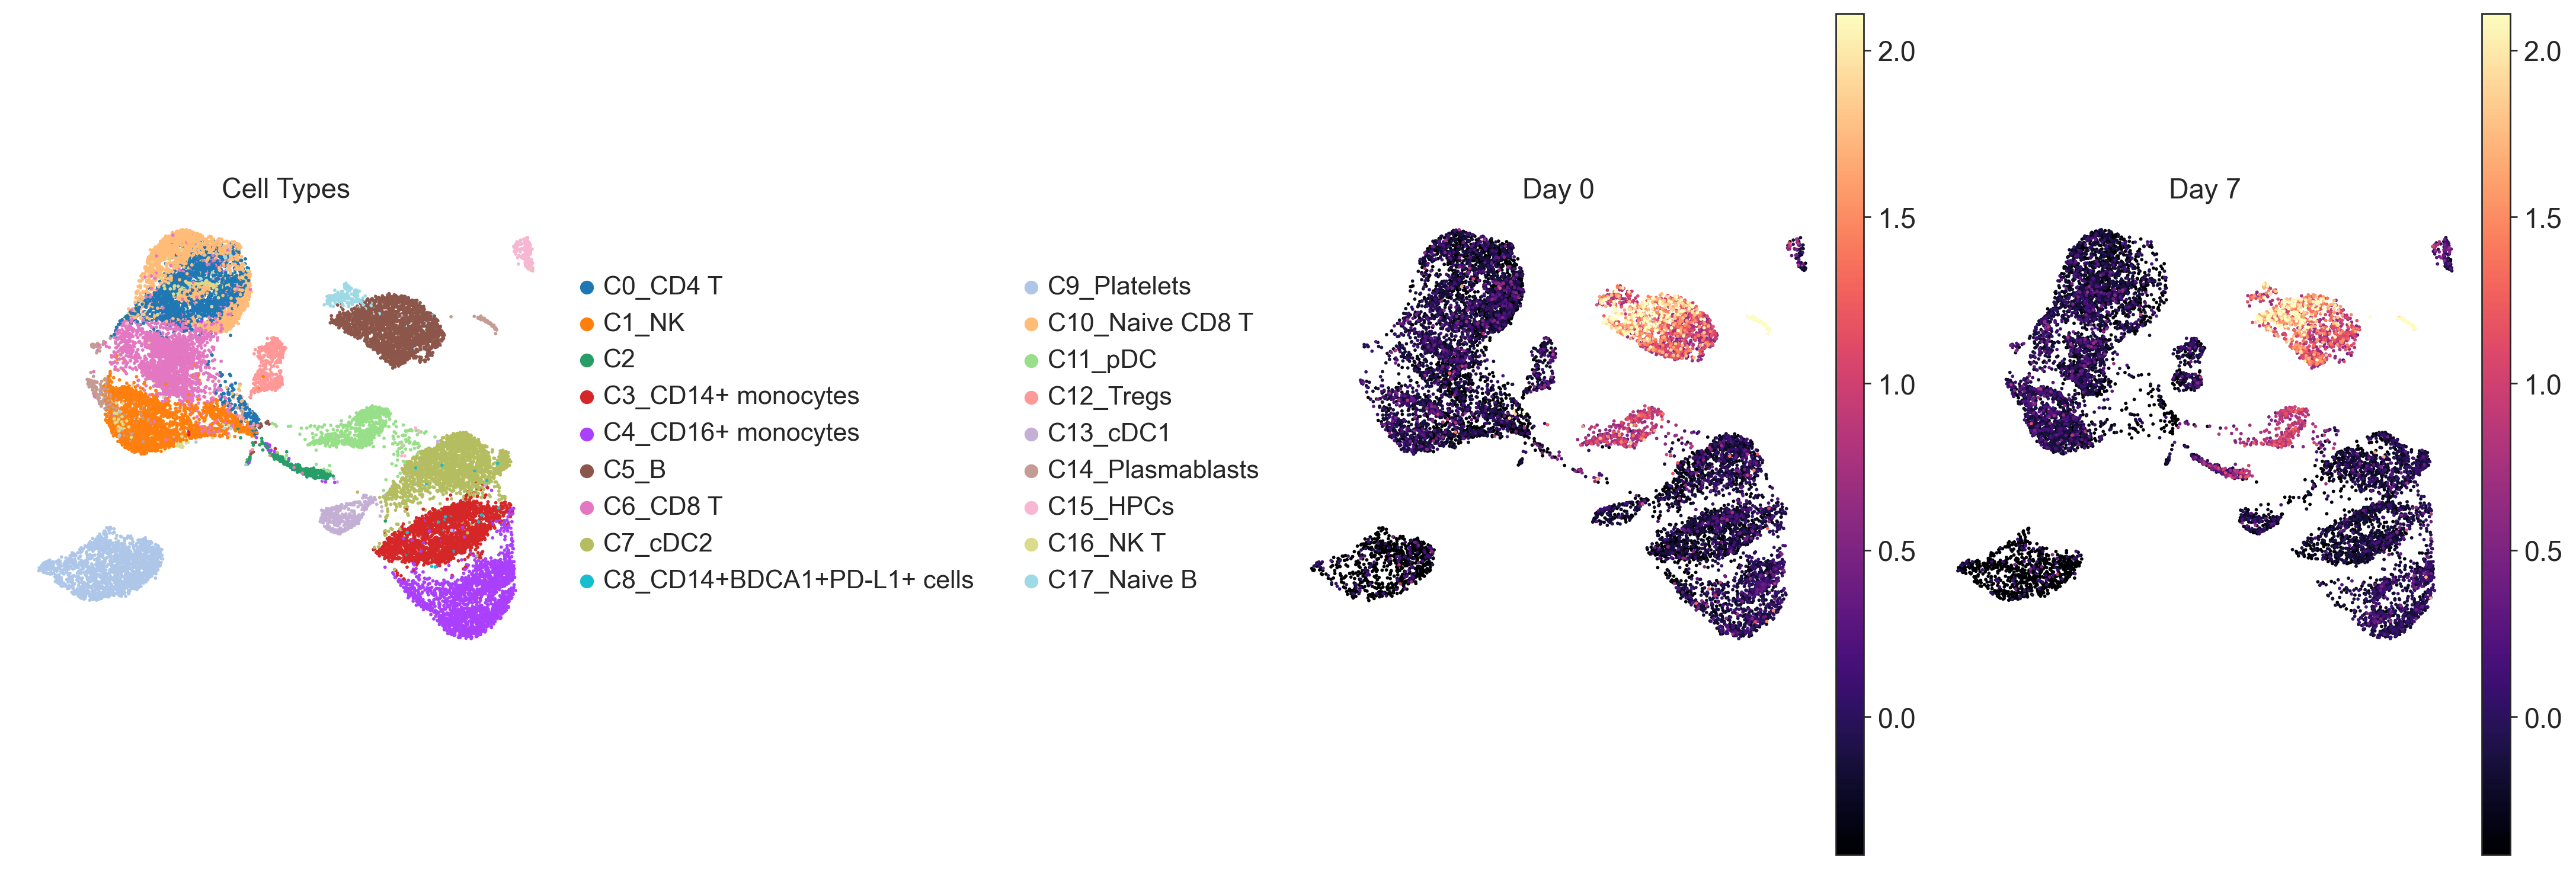

In [14]:
if features:
    feature = features[0]
    ad = adata_analysis.copy()
    ad.X = ad.layers["log1p_cpm"].copy()

    if "X_umap" not in ad.obsm:
        sc.pp.pca(ad)
        sc.pp.neighbors(ad)
        sc.tl.umap(ad)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

    # Cell type UMAP
    sc.pl.umap(
        ad,
        color=design.celltype_col,
        ax=axes[0],
        show=False,
        frameon=False,
        title="Cell Types",
        size=12,
    )
    axes[0].set_aspect('equal')

    # Feature UMAPs by visit
    vals = ad.obs[feature].values
    vmin = np.nanpercentile(vals, 1)
    vmax = np.nanpercentile(vals, 99)

    for ax, vis in zip(axes[1:], visits[:2]):
        sub = ad[ad.obs[design.visit_col] == vis].copy()
        if sub.n_obs > 0:
            sc.pl.umap(
                sub,
                color=feature,
                ax=ax,
                show=False,
                frameon=False,
                vmin=vmin,
                vmax=vmax,
                cmap="magma",
                title=f"Day {vis}",
                size=12,
            )
            ax.set_aspect('equal')
        else:
            ax.set_axis_off()

    plt.show()


## 11. Dotplot of Panel Genes

Here, we summarize gene expression patterns across cell types in a compact dotplot.


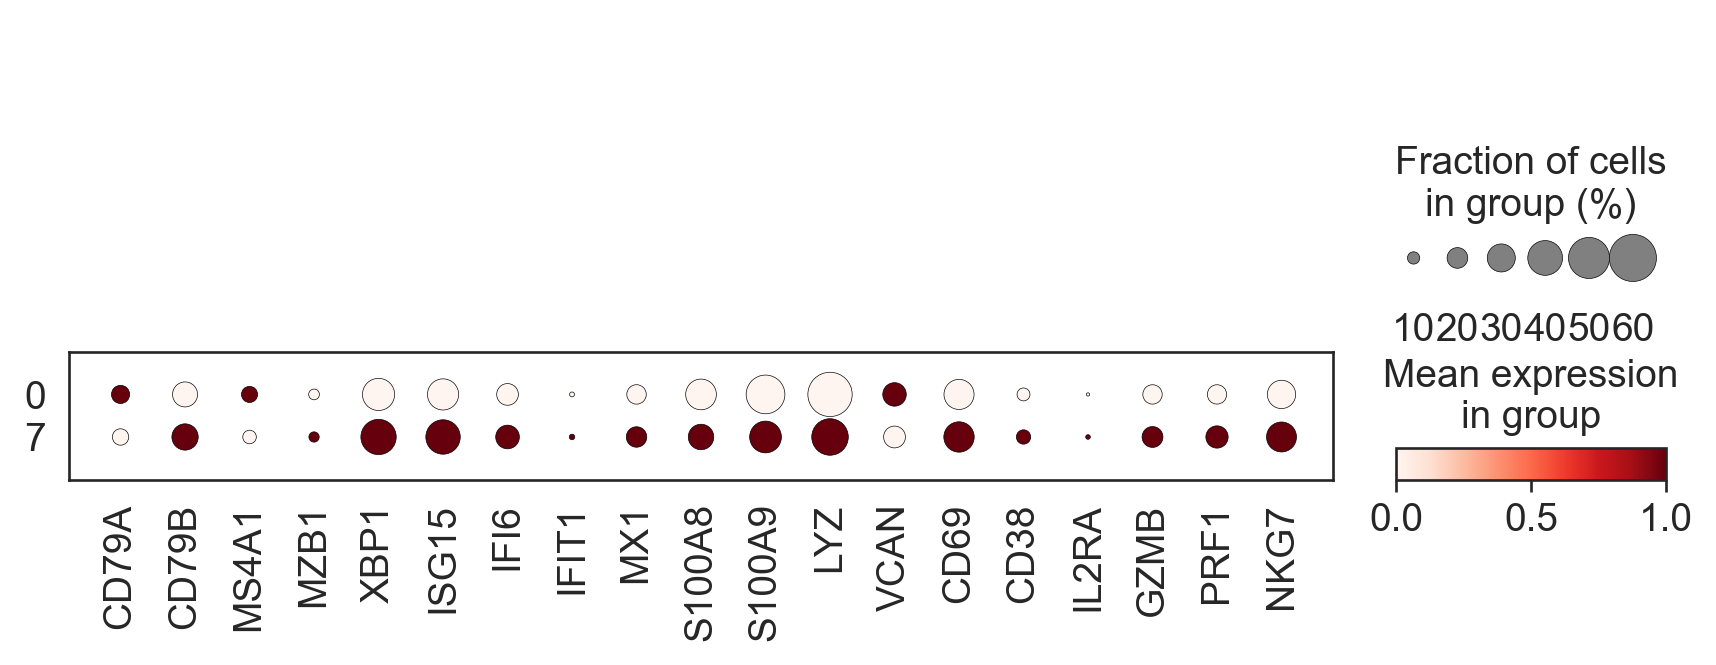

In [15]:
if panel_genes:
    sc.pl.dotplot(
        adata_analysis,
        panel_genes,
        groupby=design.visit_col,
        standard_scale="var",
        use_raw=False,
    )


## 12. Summary and Conclusions

Here, we synthesize key findings and highlight the main biological takeaways.


In [16]:
print("=" * 60)
print("ANALYSIS SUMMARY")
print("=" * 60)

print(f"""
Dataset: BNT162b2 Vaccine Response (GSE171964)
  - Total cells: {adata_analysis.n_obs:,}
  - Participants: {adata_analysis.obs['participant_id'].nunique()}
  - Cell types: {adata_analysis.obs['cell_type'].nunique()}
  - Time points: Day 0 (baseline), Day 7 (post-vaccination)

Study design:
  - Single-arm longitudinal (no unvaccinated control)
  - All analyses are within-participant paired comparisons

Longitudinal pairing:
  - Paired participants: {N_VALID_PAIRED}

Analysis approach:
  1. Module scoring (zmean method) for gene signatures
  2. Within-arm longitudinal comparisons (Day 0 vs Day 7)
  3. Pseudobulk analysis per cell type

Statistical methods:
  - Participant-level aggregation (avoids pseudoreplication)
  - Wilcoxon signed-rank test for paired comparisons
  - FDR correction for multiple testing (alpha={FDR_ALPHA})
""")

# Summary of key findings
print("")
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

# Module scores
if 'res_within' in dir() and not res_within.empty:
    sig_within = res_within[(res_within["FDR_time"].notna()) & (res_within["FDR_time"] < FDR_ALPHA)]
    if not sig_within.empty:
        print("")
        print(f"Module score changes (FDR < {FDR_ALPHA}):")
        for _, row in sig_within.iterrows():
            direction = "increased" if row.get("beta_time", 0) > 0 else "decreased"
            print(f"  {row['feature']}: {direction} (p={row['p_time']:.3f})")
    else:
        print("")
        print(f"Module scores: No significant changes (FDR < {FDR_ALPHA})")

# Panel genes
if 'res_genes' in dir() and not res_genes.empty:
    sig_genes = res_genes[(res_genes["FDR_time"].notna()) & (res_genes["FDR_time"] < FDR_ALPHA)]
    if not sig_genes.empty:
        print("")
        print(f"Panel gene changes (FDR < {FDR_ALPHA}):")
        for _, row in sig_genes.iterrows():
            direction = "increased" if row.get("beta_time", 0) > 0 else "decreased"
            print(f"  {row['feature']}: {direction} (p={row['p_time']:.3f})")
    else:
        print("")
        print(f"Panel genes: No significant changes (FDR < {FDR_ALPHA})")

# Pseudobulk
if 'pb' in dir() and not pb.empty:
    sig_pb = pb[(pb["FDR_time"].notna()) & (pb["FDR_time"] < FDR_ALPHA)]
    if not sig_pb.empty:
        print("")
        print(f"Pseudobulk changes by cell type (FDR < {FDR_ALPHA}):")
        for ct in sig_pb["celltype"].unique():
            ct_sig = sig_pb[sig_pb["celltype"] == ct]
            genes_up = ct_sig[ct_sig["mean_delta"] > 0]["feature"].tolist()
            genes_dn = ct_sig[ct_sig["mean_delta"] < 0]["feature"].tolist()
            if genes_up:
                print(f"  {ct}: {', '.join(genes_up)} increased")
            if genes_dn:
                print(f"  {ct}: {', '.join(genes_dn)} decreased")
    else:
        print("")
        print(f"Pseudobulk: No significant changes (FDR < {FDR_ALPHA})")

print("")
print("=" * 60)

ANALYSIS SUMMARY

Dataset: BNT162b2 Vaccine Response (GSE171964)
  - Total cells: 21,331
  - Participants: 6
  - Cell types: 18
  - Time points: Day 0 (baseline), Day 7 (post-vaccination)

Study design:
  - Single-arm longitudinal (no unvaccinated control)
  - All analyses are within-participant paired comparisons

Longitudinal pairing:
  - Paired participants: 6

Analysis approach:
  1. Module scoring (zmean method) for gene signatures
  2. Within-arm longitudinal comparisons (Day 0 vs Day 7)
  3. Pseudobulk analysis per cell type

Statistical methods:
  - Participant-level aggregation (avoids pseudoreplication)
  - Wilcoxon signed-rank test for paired comparisons
  - FDR correction for multiple testing (alpha=0.25)


KEY FINDINGS

Module scores: No significant changes (FDR < 0.25)

Panel gene changes (FDR < 0.25):
  IFI6: increased (p=0.000)

Pseudobulk: No significant changes (FDR < 0.25)

